# Soil Erosion Baseline LEAF Generation
Baseline soil erosion LEAF were developed for the same land use maps than SOC LEAFs. In this case, despite LEAF existing for both irrigated and rainfed land uses, there is no difference. LEAFs have been generated differentiating crop residue management practices, as well as **TODO: conventional and reduced tillage**.

As mentioned in the [Soil Erosion Documentation](../documentation/Soil_Erosion_Documentation.md), soil erosion LEAFs are generated using the RUSLE equation, which needs both soil and weather data ($R$, $K_{st}$, and $LS$), and crop and land management relaed ($C$ and $P$).

## Step 1 - RLSK Layer
A single layer is used to speed up the process, and has been generated as the simply multiplication of R$, $K_{st}$, and $LS$ rasters. 

Then, importing and familiarizing with the needed files...

In [172]:
# Modules
import sbtn_leaf.map_plotting as mp
import sbtn_leaf.map_calculations as mc
import polars as pl
import numpy as np
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio

In [2]:
# Filepaths
k_fp = "../data/soil_erosion/GloSEM_v1.1/RUSLE_KFactor_v1.1_25km.tif"
ls_fp = "../data/soil_erosion/GloSEM_v1.1/RUSLE_LSFactor_v1.1_25km.tif"
r_fp = "../data/soil_erosion/GloSEM_v1.1/RUSLE_RFactor_v1.1_25km.tif"

In [4]:
mp.inspect_raster(k_fp)

File: ../data/soil_erosion/GloSEM_v1.1/RUSLE_KFactor_v1.1_25km.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: -3.4028234663852886e+38

--- Raster Metadata ---
TIFFTAG_SOFTWARE: GDAL 3.8.1e (3080114) (4.6.0;1710;3.0.1;2.1.6;;0x10302;5.4.5;), PROJ 9.3.1 (EPSG.VERSION=v10.098;EPSG.DATE=2023-11-24;ESRI.VERSION=ArcGIS Pro 3.2;ESRI.DATE=2023-11-02;PROJ_DATA.VERSION=1.16;)
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.0046822563745081425
  Max Value: 0.05668995901942253
  Mean Value: 0.026686985045671463
  Standard Deviation: 0.007201943080872297
  Band Metadata:
    STATISTICS_MAXIMUM: 0.056689959019423
    STATISTICS_MEAN: 0.026686986377999
    STATISTICS_MINIMUM: 0.0046822563745081
    STATISTICS_SKIPFACTORX: 1
    STATISTICS_SKIPFACTORY: 1
    

Raster has 24,328 unique values. Min: 0.00. Max: 0.06
Using quantiles
All positives route (quantiles)


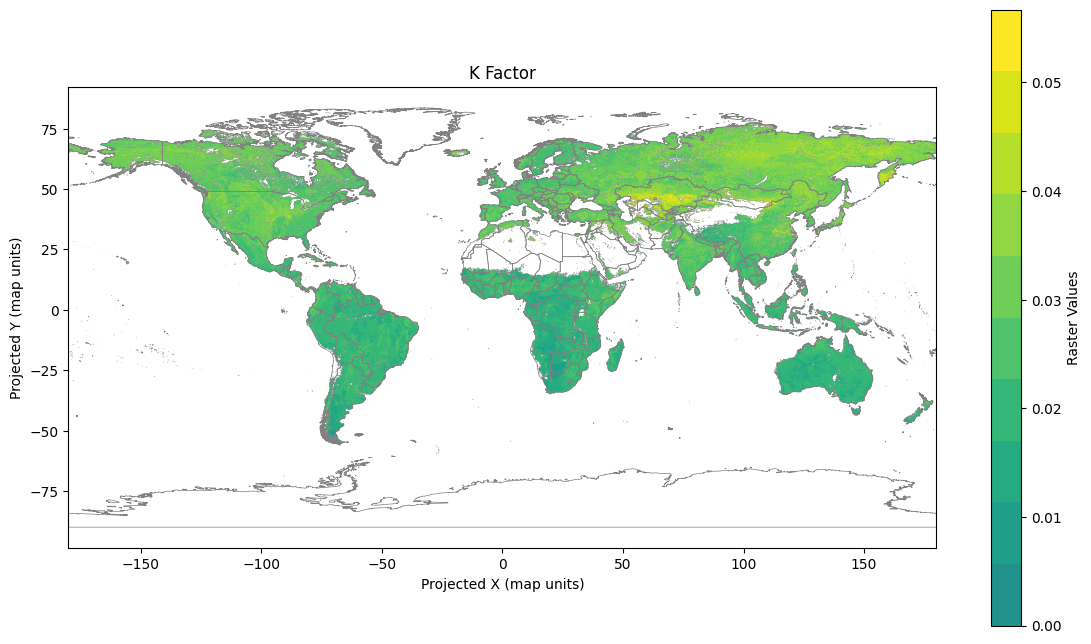

In [6]:
mp.plot_raster_on_world_extremes_cutoff(k_fp, "K Factor", perc_cutoff=0, quantiles=10)

Raster has 220,799 unique values. Min: 0.15. Max: 38.19
Using quantiles
All positives route (quantiles)


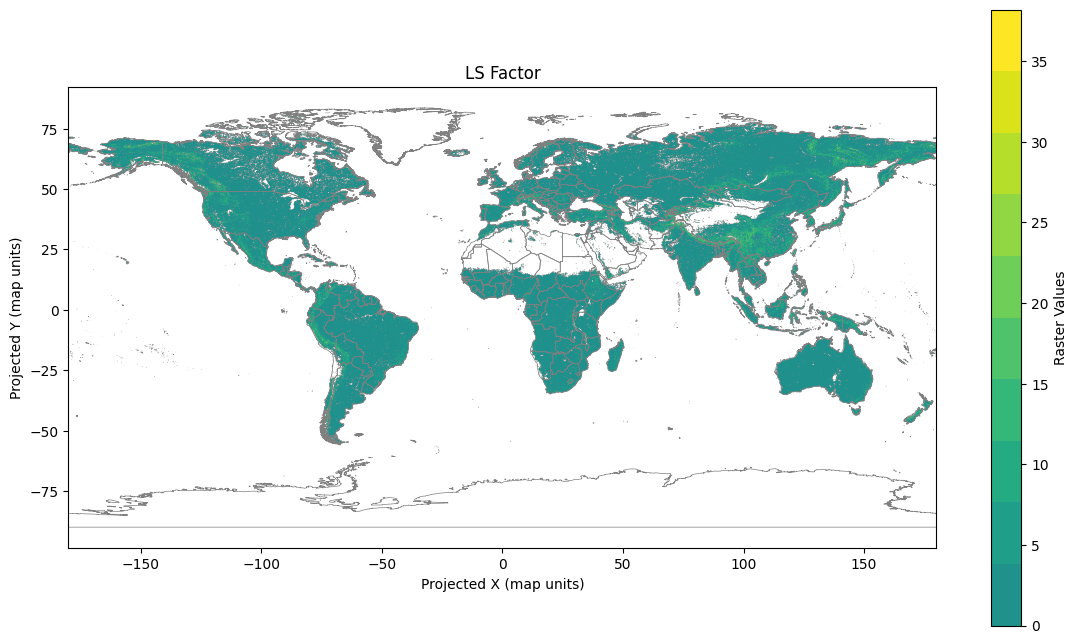

In [7]:
mp.plot_raster_on_world_extremes_cutoff(ls_fp, "LS Factor", perc_cutoff=0, quantiles=10)

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:219: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:91: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 277,777 unique values. Min: 0.00. Max: 26,179.59
Using quantiles
All positives route (quantiles)


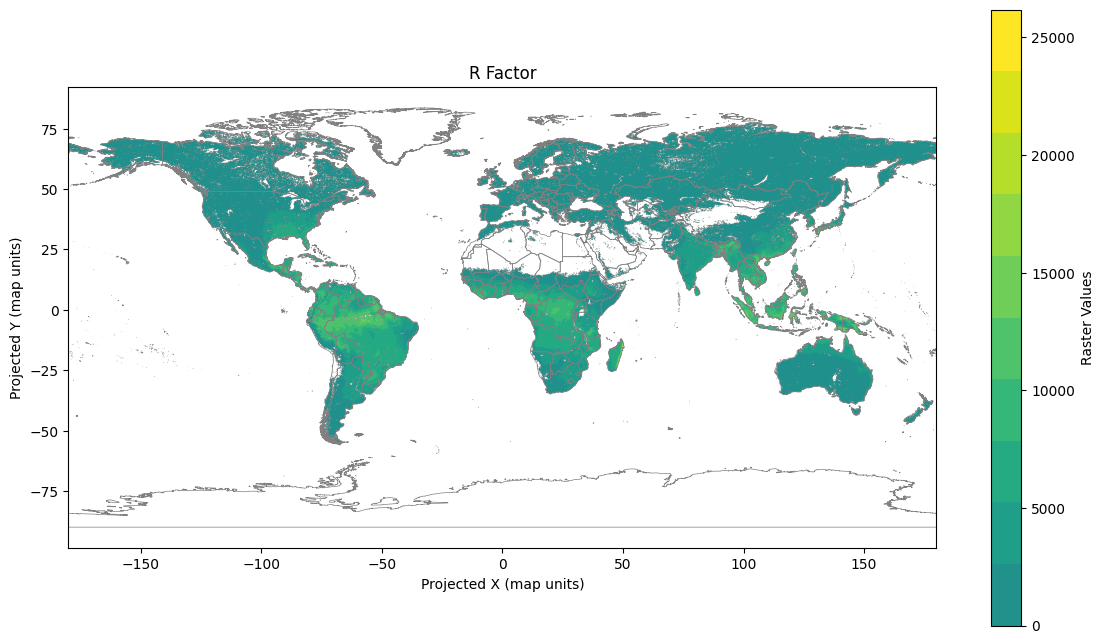

In [8]:
mp.plot_raster_on_world_extremes_cutoff(r_fp, "R Factor", perc_cutoff=0, quantiles=10)

In [9]:
mp.inspect_raster(ls_fp)

File: ../data/soil_erosion/GloSEM_v1.1/RUSLE_LSFactor_v1.1_25km.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: -3.4028234663852886e+38

--- Raster Metadata ---
TIFFTAG_SOFTWARE: GDAL 3.8.1e (3080114) (4.6.0;1710;3.0.1;2.1.6;;0x10302;5.4.5;), PROJ 9.3.1 (EPSG.VERSION=v10.098;EPSG.DATE=2023-11-24;ESRI.VERSION=ArcGIS Pro 3.2;ESRI.DATE=2023-11-02;PROJ_DATA.VERSION=1.16;)
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.15429238975048065
  Max Value: 38.18529510498047
  Mean Value: 1.7793327569961548
  Standard Deviation: 3.262052059173584
  Band Metadata:
    STATISTICS_MAXIMUM: 38.18529510498
    STATISTICS_MEAN: 1.7793328181477
    STATISTICS_MINIMUM: 0.15429238975048
    STATISTICS_SKIPFACTORX: 1
    STATISTICS_SKIPFACTORY: 1
    STATISTICS_STDD

As expected from sourcing all layers from a single reference, they all coincide in their GIS properties and can be multiplied without further transformations.

In [13]:
# Defining raster list
rlsk_inputs = [r_fp, ls_fp, k_fp]
rlsk_fp = "../data/soil_erosion/rlsk_2012.tif"

rlsk = mc.multiply_rasters(rlsk_inputs, output_path=rlsk_fp)

Raster saved into ../data/soil_erosion/rlsk_2012.tif


Inspecting the results...

In [11]:
mp.inspect_raster(rlsk_fp)

File: ../data/soil_erosion/rlsk_2012.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: -1.7976931348623157e+308

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float64
  Min Value: 0.0
  Max Value: 10179.745188638457
  Mean Value: 96.62198062560604
  Standard Deviation: 294.14528533731226


C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:219: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:91: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 278,031 unique values. Min: 0.00. Max: 10,179.75
Using quantiles
All positives route (quantiles)


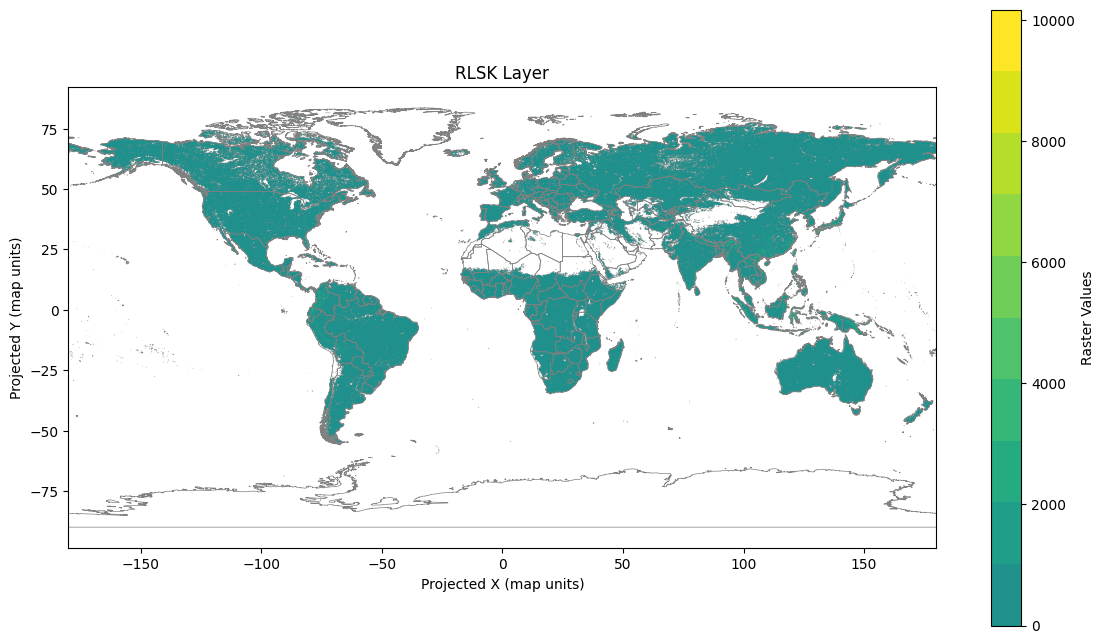

In [16]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/rlsk_2012.tif", title="RLSK Layer", perc_cutoff=0, quantiles=10)

Which shows that the layer has been correctly generated. Moving on.

## Step 2 - Crop C-Factor
Next step is generating a layer of C factors for each land use map. In this case, C-factors are assigned according to tables 1 and 2 of Soil Erosion Documentation, which have been pre-assigned and can be found on the file [`lu_c_factor_inventory`](../data/crops/lu_c_factor_inventory.xlsx). This file additionally contains all raster names, paths, commodities and their categorization, irrigation type, and crop residues management type.

Importing the file and inspecting the file

In [173]:
rlsk_fp = "../data/soil_erosion/rlsk_2012.tif"

In [174]:
files_inventory = pl.read_excel("../data/crops/lu_c_factor_inventory.xlsx")

In [175]:
files_inventory.head(15)

file_name,land_use,path,crop_name,irrigation_type,on_off_field,commodity_type,crop_type,crop_class,crop_subclass,c_crop,c_res,c_final
str,str,str,str,str,str,str,str,str,str,f64,f64,f64
"""lu_Broadleaf_Deciduous_Boreal_…","""Broadleaf_Deciduous_Boreal_dry""","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Boreal_dry""","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Boreal_…","""Broadleaf_Deciduous_Boreal_moi…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Boreal_moi…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Cold_te…","""Broadleaf_Deciduous_Cold_tempe…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Cold_tempe…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Cold_te…","""Broadleaf_Deciduous_Cold_tempe…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Cold_tempe…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
"""lu_Broadleaf_Deciduous_Subtrop…","""Broadleaf_Deciduous_Subtropica…","""../data/land_use/lu_Broadleaf_…","""Broadleaf_Deciduous_Subtropica…","""NA""","""NA""","""Forest""",null,"""Forest""","""Natural""",0.003,1.0,0.003
…,…,…,…,…,…,…,…,…,…,…,…,…
"""lu_Irrigated_Bananas.tif""","""Irrigated_Bananas""","""C:\Users\loyola\OneDrive - Wor…","""Bananas""","""Irrigated""","""NA""","""permanent_crop""","""permanent""","""Fruit_Trees""","""Various""",0.15,1.0,0.15
"""lu_Irrigated_Barley_residues_l…","""Irrigated_Barley_residues_left…","""C:\Users\loyola\OneDrive - Wor…","""Barley""","""Irrigated""","""on""","""annual_crop""","""annual""","""Cereals""","""Various""",0.2,0.88,0.176
"""lu_Irrigated_Barley_residues_r…","""Irrigated_Barley_residues_remo…","""C:\Users\loyola\OneDrive - Wor…","""Barley""","""Irrigated""","""off""","""annual_crop""","""annual""","""Cereals""","""Various""",0.2,1.0,0.2


Next step is to generate the C-Factor value in the original land use raster resolution (~10km) and then downsampling to 25km from the RLSK layer. The 10km files have not been preserved, but can be generated as follow:

In [176]:
output_folder = "../data/soil_erosion/C_Factors/10km/"

In [204]:
import rasterio
import numpy as np
import xarray as xr

In [205]:
with rasterio.open("../data/land_use/lu_Broadleaf_Deciduous_Boreal_dry.tif") as src:
    # Read the specified band from the raster.
    data = src.read(1)
    # Use the manual_nodata if provided; otherwise use the file's nodata.
    nodata = src.nodata
    # Copy metadata from the source for writing the new GeoTIFF.
    meta = src.meta.copy()

# valid layer
valid = (data != nodata) & ~np.isnan(data)

out = np.where(valid, 0.003, np.nan)


height, width = out.shape
transform = meta["transform"]

xs = np.array([transform * (col + 0.5, 0) for col in range(width)])[:, 0]
ys = np.array([transform * (0, row + 0.5) for row in range(height)])[:, 1]

da = xr.DataArray(
    out.astype(np.float32),
    dims=["y", "x"],
    coords={"y": ys, "x": xs},
    attrs={"crs": meta["crs"].to_string(), "nodata": np.nan}
)
    

Raster has 1 unique values. Min: 0.00. Max: 0.00


(<Figure size 1400x800 with 2 Axes>,
 <Axes: title={'center': 'test'}, xlabel='Projected X (map units)', ylabel='Projected Y (map units)'>)

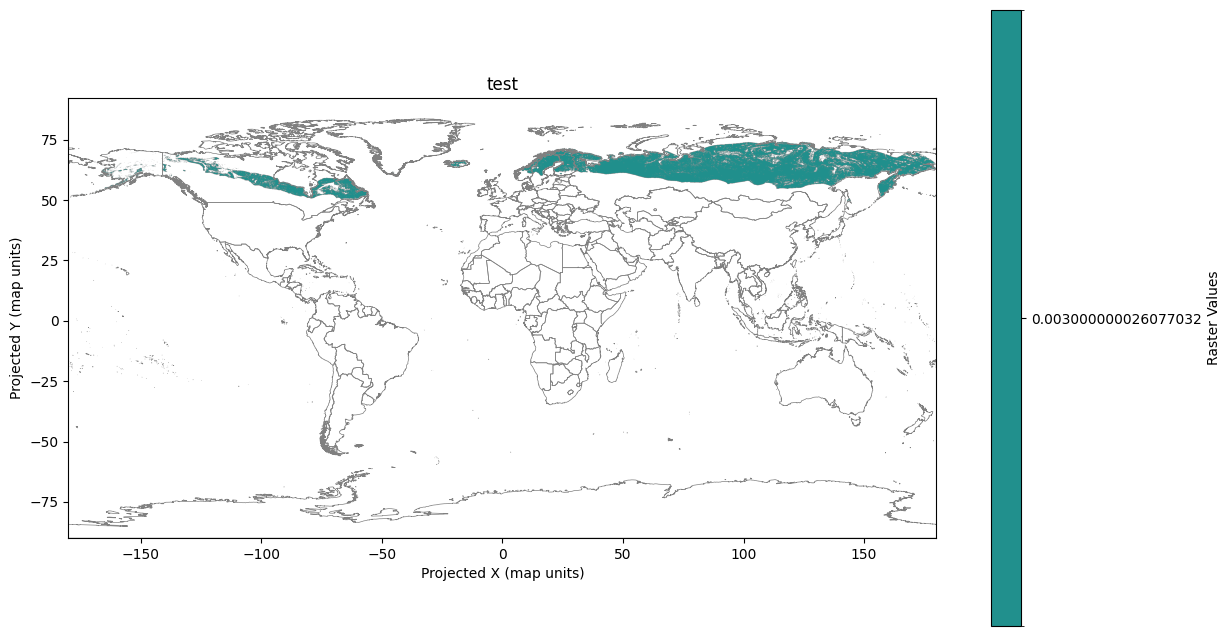

In [206]:
mp.plot_da_on_world_extremes_cutoff(da, "test")

In [207]:
for row in files_inventory.iter_rows(named=True):
    input_path = row["path"]
    c_factor = row["c_final"]
    land_use_type = row["land_use"]
    output_path = output_folder + "cfactor_10km_" + land_use_type + ".tif"

    print(f"Rasterizing {land_use_type} land use with a c factor of {c_factor}")

    mc.create_binary_mask(input_path, output_path, binary_value=c_factor, dst_nodata=np.nan)
    print(f"{land_use_type} rasterized succesfully!\n")

Rasterizing Broadleaf_Deciduous_Boreal_dry land use with a c factor of 0.003
Input No Data defined as 255.0. Value 0.003 if is not 255.0 and nan if it is.
0.003
Broadleaf_Deciduous_Boreal_dry rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Boreal_moist land use with a c factor of 0.003
Input No Data defined as 255.0. Value 0.003 if is not 255.0 and nan if it is.
0.003
Broadleaf_Deciduous_Boreal_moist rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Cold_temperate_dry land use with a c factor of 0.003
Input No Data defined as 255.0. Value 0.003 if is not 255.0 and nan if it is.
0.003
Broadleaf_Deciduous_Cold_temperate_dry rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Cold_temperate_moist land use with a c factor of 0.003
Input No Data defined as 255.0. Value 0.003 if is not 255.0 and nan if it is.
0.003
Broadleaf_Deciduous_Cold_temperate_moist rasterized succesfully!

Rasterizing Broadleaf_Deciduous_Subtropical land use with a c factor of 0.003
Input No Data 

In [208]:
mp.inspect_raster("../data/soil_erosion/C_Factors/10km/cfactor_10km_Needleleaf_Evergreen_Boreal_dry.tif")

File: ../data/soil_erosion/C_Factors/10km/cfactor_10km_Needleleaf_Evergreen_Boreal_dry.tif
Driver: GTiff
Width, Height: 4320, 2083
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-179.99999999999997, bottom=-89.99999999999994, right=179.99999999999991, top=83.58333333333331)
Pixel Size: (0.0833333333333333, 0.0833333333333333)
No-data Value: nan

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 9.999999747378752e-05
  Max Value: 9.999999747378752e-05
  Mean Value: 9.99999901978299e-05
  Standard Deviation: 7.275957614183426e-12


Raster has 1 unique values. Min: 0.00. Max: 0.00


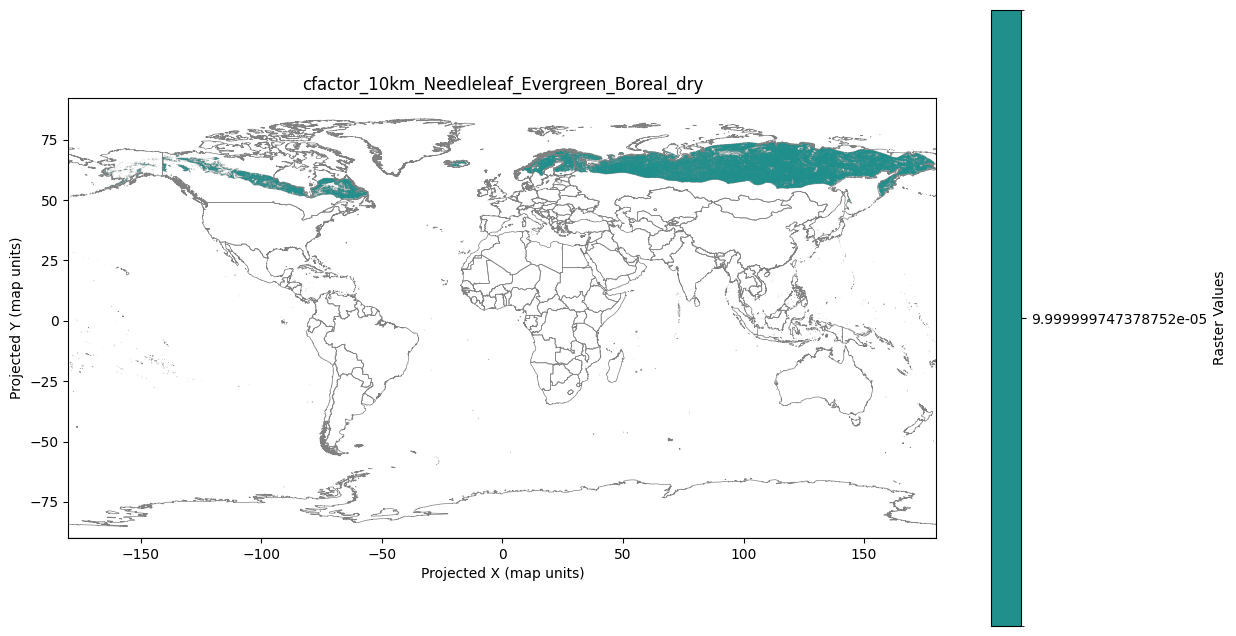

In [189]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/C_Factors/10km/cfactor_10km_Needleleaf_Evergreen_Boreal_dry.tif", "cfactor_10km_Needleleaf_Evergreen_Boreal_dry", eliminate_zeros=False)

Raster has 1 unique values. Min: 0.15. Max: 0.15


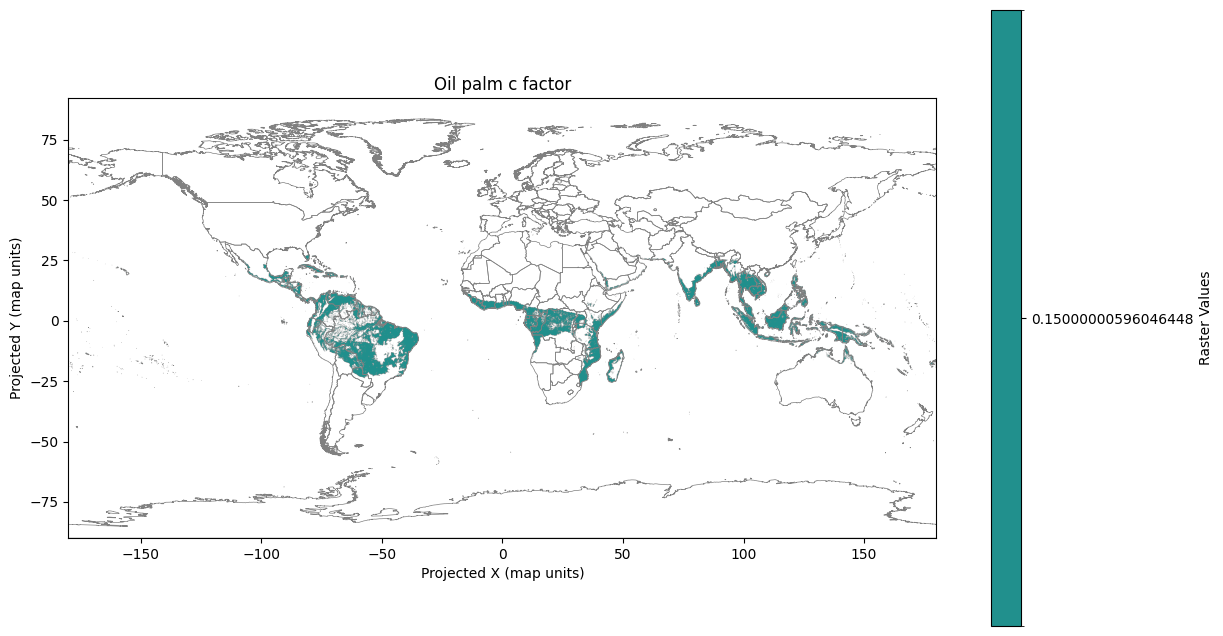

In [209]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/C_Factors/10km/cfactor_10km_Irrigated_Oil_palm.tif", "Oil palm c factor", eliminate_zeros=True)

And the downsampling can be perform then as:

In [14]:
input_folder = "../data/soil_erosion/C_Factors/10km/"
output_folder = "../data/soil_erosion/C_Factors/25km/"

for file in os.listdir(input_folder):
    # file names
    file_name = os.path.basename(file)
    new_file_name = file_name.replace("10km", "25km")
    input_path = input_folder + file_name
    output_path = output_folder + new_file_name
    
    # Operation
    mc.resample_to_match(src_path=input_path, target_path=rlsk_fp, output_path=output_path)
    print(f"{file_name} resampled into rlsk raster resolution")
    

cfactor_10km_Barley_irr_roff_rt.tif resampled into rlsk raster resolution
cfactor_10km_Barley_irr_ron_rt.tif resampled into rlsk raster resolution
cfactor_10km_Barley_rf_roff_rt.tif resampled into rlsk raster resolution
cfactor_10km_Barley_rf_ron_rt.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Boreal_dry.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Boreal_moist.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Cold_temperate_dry.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Cold_temperate_moist.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Subtropical.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Tropical.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Warm_temperate_dry.tif resampled into rlsk raster resolution
cfactor_10km_Broadleaf_Deciduous_Warm_temperate_moist.tif resampled into rlsk r

Inpsecting wheat as it has both crop residues management options

In [15]:
mp.inspect_raster("../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_removed_from_the_field.tif")

File: ../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_removed_from_the_field.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: nan

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.20000000298023224
  Max Value: 0.20000000298023224
  Mean Value: 0.20000001788139343
  Standard Deviation: 1.4901161193847656e-08


Raster has 1 unique values. Min: 0.20. Max: 0.20


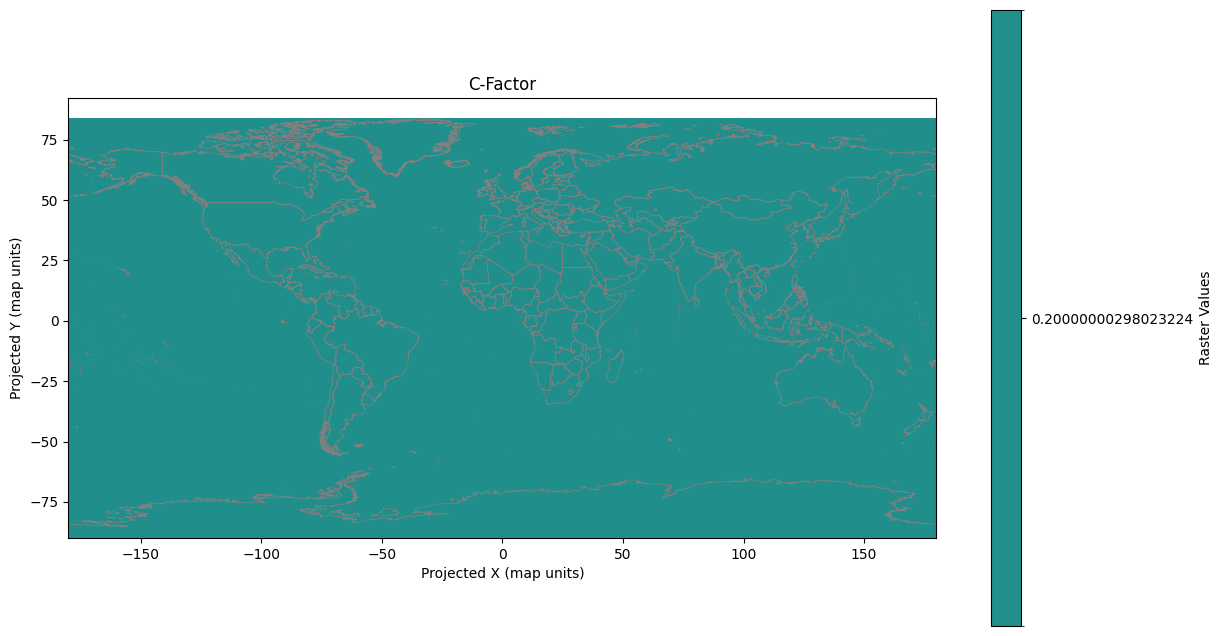

In [17]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/C_Factors/10km/cfactor_10km_Rainfed_Wheat_residues_removed_from_the_field.tif", "C-Factor", perc_cutoff=0, eliminate_zeros=True)

In [18]:
mp.inspect_raster("../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_left_on_the_field.tif")

File: ../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_left_on_the_field.tif
Driver: GTiff
Width, Height: 1728, 673
Number of Bands: 1
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-56.6229166666667, right=179.99999999999943, top=83.58541666666642)
Pixel Size: (0.208333333333333, 0.208333333333333)
No-data Value: nan

--- Raster Metadata ---
AREA_OR_POINT: Area

--- Band Information ---

Band 1:
  Data Type: float32
  Min Value: 0.17599999904632568
  Max Value: 0.17599999904632568
  Mean Value: 0.17599999904632568
  Standard Deviation: 0.0


Raster has 1 unique values. Min: 0.18. Max: 0.18


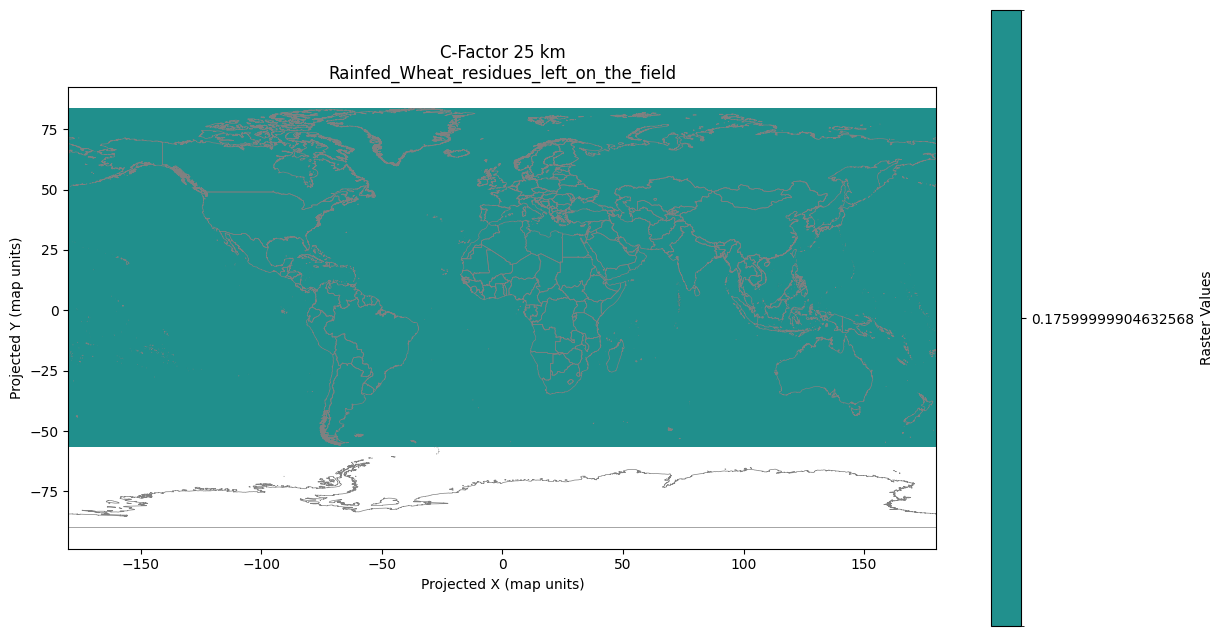

In [19]:
mp.plot_raster_on_world_extremes_cutoff("../data/soil_erosion/C_Factors/25km/cfactor_25km_Rainfed_Wheat_residues_left_on_the_field.tif", "C-Factor 25 km\nRainfed_Wheat_residues_left_on_the_field", perc_cutoff=0)

## Step 3 - Calculate LEAFs Soil Erosion for each land use
Now that both the RLSK layer and the C-Factor layers have been generated, soil erosion factors can be simply calculated as the multiplication of both. 

This can be done as:

In [20]:
input_folder = "../data/soil_erosion/C_Factors/25km/"
output_folder = "../LEAFs/soil_erosion/"

for file in os.listdir(input_folder):
    # file names
    file_name = os.path.basename(file)
    new_file_name = file_name.replace("cfactor", "se_rate")
    input_path = input_folder + file_name
    output_path = output_folder + new_file_name
    
    # Operation
    mc.multiply_rasters([rlsk_fp, input_path], output_path)
    print(f"Soil erosion calculated for {file_name}")

Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_irr_roff_rt.tif
Soil erosion calculated for cfactor_25km_Barley_irr_roff_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_irr_ron_rt.tif
Soil erosion calculated for cfactor_25km_Barley_irr_ron_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_rf_roff_rt.tif
Soil erosion calculated for cfactor_25km_Barley_rf_roff_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Barley_rf_ron_rt.tif
Soil erosion calculated for cfactor_25km_Barley_rf_ron_rt.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif
Soil erosion calculated for cfactor_25km_Broadleaf_Deciduous_Boreal_dry.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Broadleaf_Deciduous_Boreal_moist.tif
Soil erosion calculated for cfactor_25km_Broadleaf_Deciduous_Boreal_moist.tif
Raster saved into ../LEAFs/soil_erosion/se_rate_25km_Broadleaf_Deciduous_Cold_temperate_dry.tif
Soil erosion calcula

Inpsecting the same land use as before...

In [21]:
wheat_ron_se_leaf_fp = "../LEAFs/soil_erosion/raster/se_rate_25km_Rainfed_Wheat_residues_left_on_the_field.tif"
wheat_roff_se_leaf_fp = "../LEAFs/soil_erosion/raster/se_rate_25km_Rainfed_Wheat_residues_removed_from_the_field.tif"

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 157,950 unique values. Min: 0.12. Max: 259.92
Using quantiles
All positives route (quantiles)


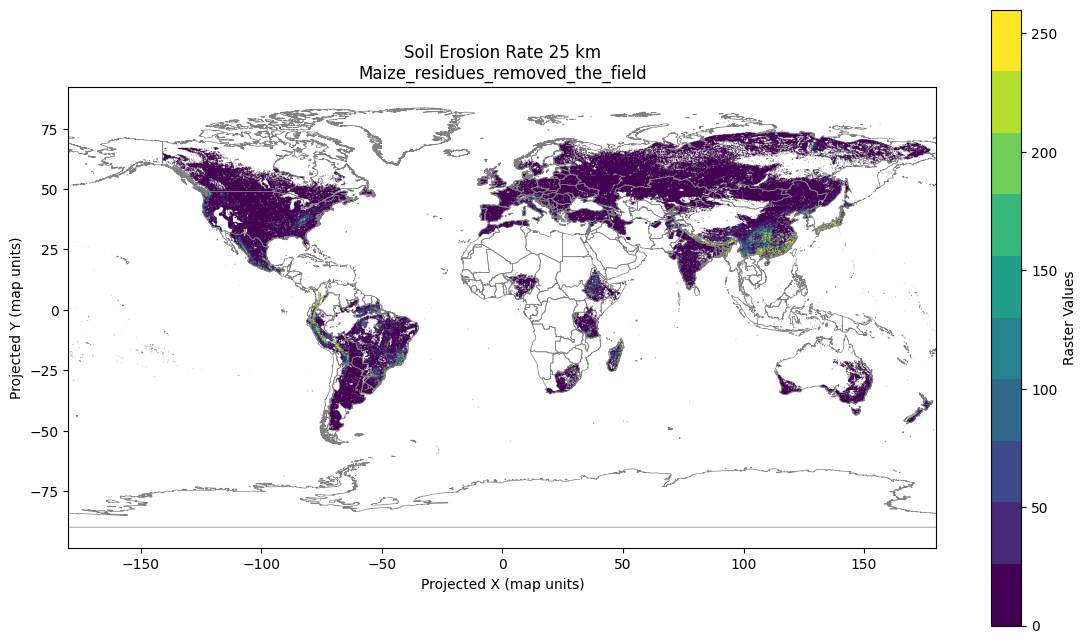

In [23]:
mp.plot_raster_on_world_extremes_cutoff(wheat_roff_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_removed_the_field", perc_cutoff=1, quantiles=10)

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 163,785 unique values. Min: 0.00. Max: 1,791.64
Using quantiles
All positives route (quantiles)


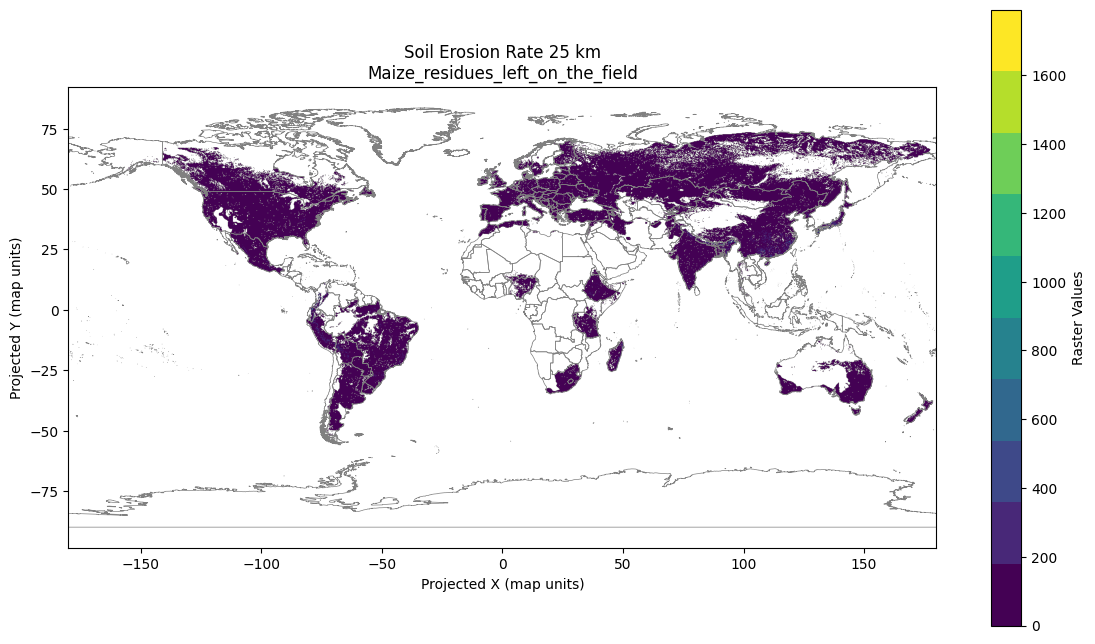

In [24]:
mp.plot_raster_on_world_extremes_cutoff(wheat_ron_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_left_on_the_field", perc_cutoff= 0, quantiles=10)

As it can be seen, there seems to be some outliers, with same erosion rates going over 1,000 ton soil per year. Plotting with a 95% range of values:

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 145,046 unique values. Min: 0.24. Max: 86.62
Using quantiles
All positives route (quantiles)


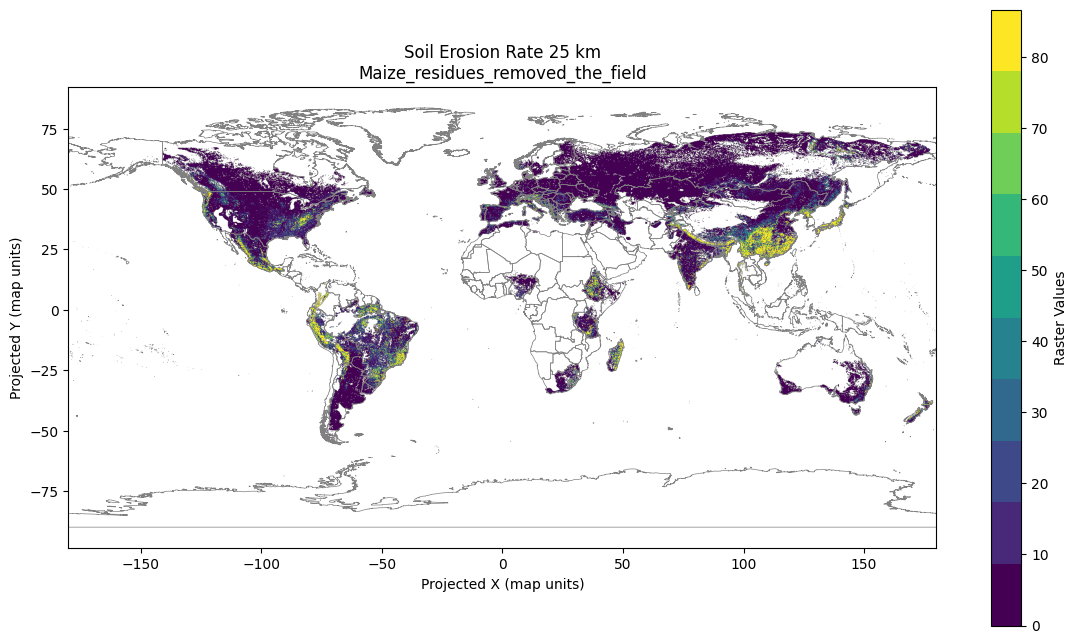

In [25]:
mp.plot_raster_on_world_extremes_cutoff(wheat_roff_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_removed_the_field", perc_cutoff=5, quantiles=10)

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 147,753 unique values. Min: 0.21. Max: 76.11
Using quantiles
All positives route (quantiles)


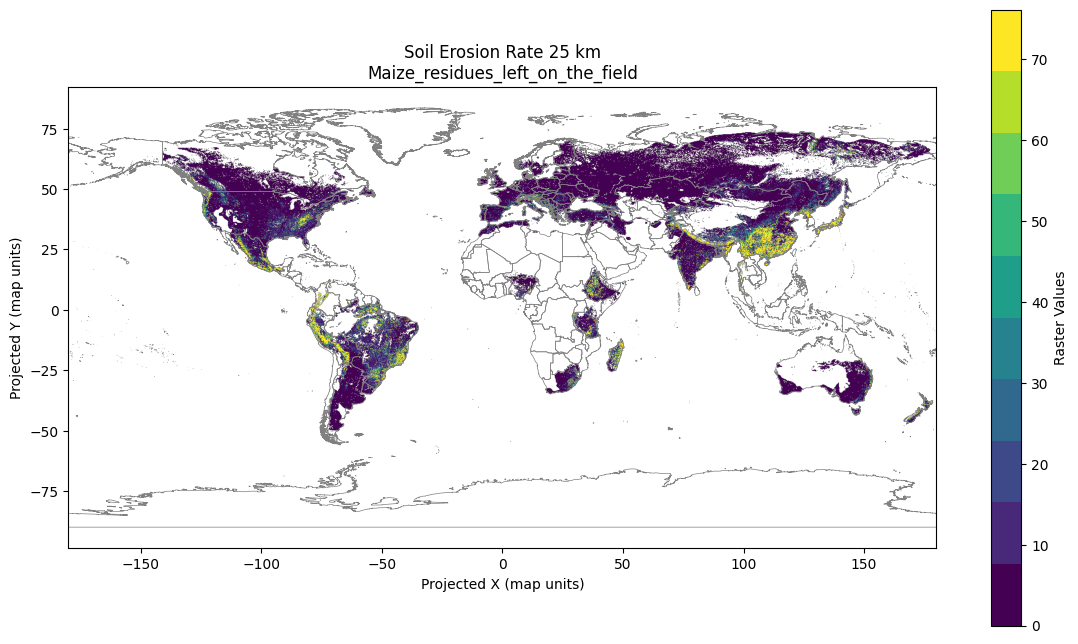

In [26]:
mp.plot_raster_on_world_extremes_cutoff(wheat_ron_se_leaf_fp, "Soil Erosion Rate 25 km\nMaize_residues_left_on_the_field", perc_cutoff=5, quantiles=10)

It shows a much more sensible map. It also shows that the maximum rates for leaving residues on the field erosion rates are lower, as expected.

### Clipping to X%


First, writing the functions to filter. This will be exported to map_calculations when they're working

In [37]:
from pathlib import Path
from scipy import ndimage
from typing import Optional, Tuple, List

In [41]:
def _apply_log_winsor(array: np.ndarray, bounds: Tuple[float, float]) -> np.ndarray:
    """Winsorize *array* in log1p space then invert back to original scale.

    Only finite values are modified; NaN/Inf pass through unchanged.
    Values must be > -1 (required for log1p).
    """
    q_lo, q_hi = bounds
    if not (0 <= q_lo < q_hi <= 100):
        raise ValueError("log_winsor_bounds must satisfy 0 <= lo < hi <= 100")

    result = array.copy().astype("float32", copy=False)
    valid = np.isfinite(array)

    if not np.any(valid):
        return result

    vals = array[valid].astype("float64", copy=False)
    if np.nanmin(vals) <= -1.0:
        raise ValueError(
            f"log_winsor requires all finite values > -1; found min={np.nanmin(vals)}"
        )

    log_vals = np.log1p(vals)
    lo, hi = np.percentile(log_vals, [q_lo, q_hi])
    clipped = np.expm1(np.clip(log_vals, lo, hi))
    result[valid] = clipped.astype("float32", copy=False)
    return result


def _apply_local_zscore(
    array: np.ndarray,
    *,
    local_window: int,
    local_k: float,
    local_min_neighbors: int,
) -> np.ndarray:
    """Clip *array* to ±local_k local standard deviations within a sliding window.

    Pixels with fewer than *local_min_neighbors* valid neighbors in the window
    are left unchanged.  NaN/Inf pixels are never modified.
    """
    if local_window <= 0 or local_window % 2 == 0:
        raise ValueError("local_window must be a positive odd integer")

    valid = np.isfinite(array)
    if not np.any(valid):
        return array.copy()

    val = np.where(valid, array, 0.0).astype("float32", copy=False)
    val2 = np.where(valid, array * array, 0.0).astype("float32", copy=False)
    valid_f = valid.astype("float32", copy=False)

    size = (local_window, local_window)
    win_area = local_window * local_window

    neighbor_count = ndimage.uniform_filter(valid_f, size=size, mode="nearest") * win_area
    sum_local = ndimage.uniform_filter(val, size=size, mode="nearest") * win_area
    sumsq_local = ndimage.uniform_filter(val2, size=size, mode="nearest") * win_area

    with np.errstate(invalid="ignore", divide="ignore"):
        local_mean = np.divide(sum_local, neighbor_count, where=neighbor_count > 0)
        local_var = (
            np.divide(sumsq_local, neighbor_count, where=neighbor_count > 0)
            - local_mean * local_mean
        )

    local_std = np.sqrt(np.maximum(local_var, 0.0))
    enough = neighbor_count >= local_min_neighbors

    lower = local_mean - local_k * local_std
    upper = local_mean + local_k * local_std

    result = array.copy()
    clip_mask = valid & enough
    result[clip_mask] = np.clip(array[clip_mask], lower[clip_mask], upper[clip_mask])
    return result



def filter_raster_outliers(
    input_path,
    output_path=None,
    *,
    log_winsor_bounds: Optional[Tuple[float, float]] = None,
    apply_local_zscore: bool = False,
    local_window: int = 11,
    local_k: float = 2.5,
    local_min_neighbors: int = 20,
    global_percentile_cap: Optional[float] = None,
    bands: Optional[List[int]] = None,
    overwrite: bool = False,
    output_nodata: float = np.nan
) -> str:
    """Filter outliers from a raster using log winsorization and/or local z-score clipping.

    Reads the input GeoTIFF, applies the requested filters in order:
      1. ``log_winsor_bounds`` — winsorize each band in log1p space, then invert.
      2. ``apply_local_zscore`` — spatially clip each pixel to ±local_k local
         standard deviations within a sliding ``local_window × local_window`` kernel.
      3. ``global_percentile_cap`` — cap all finite values at this percentile
         (applied across all selected bands after the above steps).

    Parameters
    ----------
    input_path : path-like
        Path to the input GeoTIFF.
    output_path : path-like or None
        Destination path.  When *None*, overwrites *input_path* (requires
        ``overwrite=True``).
    log_winsor_bounds : (lo, hi) or None
        Percentile pair in [0, 100] used to winsorize in log1p space.
        All finite values must be > -1.  Example: ``(0.5, 99.5)``.
    apply_local_zscore : bool
        When *True*, apply a spatial local z-score clip after log winsorization.
    local_window : int
        Odd kernel size (pixels) for the local z-score sliding window.
    local_k : float
        Number of local standard deviations defining the clip bounds.
    local_min_neighbors : int
        Minimum valid neighbors a pixel must have before local clipping is applied.
    global_percentile_cap : float or None
        If set, cap all finite values at this percentile across selected bands.
        Applied last, after all other filters.
    bands : list[int] or None
        0-based band indices to process.  *None* means all bands.
    overwrite : bool
        Must be *True* to allow in-place overwrite when *output_path* is None.

    Returns
    -------
    str
        Path of the written output file.
    """
    input_path = Path(input_path)
    if output_path is None:
        if not overwrite:
            raise ValueError(
                "output_path is None — set overwrite=True to overwrite the input file"
            )
        output_path = input_path
    else:
        output_path = Path(output_path)

    if apply_local_zscore and local_window % 2 == 0:
        raise ValueError("local_window must be a positive odd integer")

    with rasterio.open(input_path) as src:
        profile = src.profile.copy()
        data = src.read().astype("float32")
        nodata = src.nodata
        tags = src.tags()

    # Replace nodata with NaN so filters can ignore them uniformly
    if nodata is not None:
        data[data == nodata] = np.nan

    n_bands = data.shape[0]
    band_indices = list(range(n_bands)) if bands is None else list(bands)

    for bi in band_indices:
        band = data[bi]

        if log_winsor_bounds is not None:
            band = _apply_log_winsor(band, log_winsor_bounds)

        if apply_local_zscore:
            band = _apply_local_zscore(
                band,
                local_window=local_window,
                local_k=local_k,
                local_min_neighbors=local_min_neighbors,
            )

        data[bi] = band

    if global_percentile_cap is not None:
        all_finite = np.concatenate(
            [data[bi][np.isfinite(data[bi])].ravel() for bi in band_indices]
        )
        if all_finite.size > 0:
            cap_val = np.nanpercentile(all_finite, global_percentile_cap)
            for bi in band_indices:
                finite = np.isfinite(data[bi])
                data[bi] = np.where(finite, np.minimum(data[bi], cap_val), data[bi])

    # Restore nodata
    if output_nodata is not None:
        data[~np.isfinite(data)] = output_nodata
    else:
        data[~np.isfinite(data)] = nodata

    output_path.parent.mkdir(parents=True, exist_ok=True)
    profile.update(dtype="float32", nodata = output_nodata)
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(data)
        dst.update_tags(**tags)

    return str(output_path)

Testing the function

In [45]:
test_fp = "../LEAFs/soil_erosion/raster/se_rate_25km_Barley_irr_roff_rt.tif"
output_test_path= "../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_Barley_irr_roff_rt_clipped.tif"
output_clipped_rasters = "../LEAFs/soil_erosion/rasters_clipped"
log_winsor_bounds = (0.5, 99.5)

In [50]:
filter_raster_outliers(
    input_path=test_fp,
    output_path= output_test_path,
    log_winsor_bounds=log_winsor_bounds,
    apply_local_zscore=True,
    local_window=3,
    local_k=2.5,
    local_min_neighbors=20,
    global_percentile_cap=99.5
)

C:\Users\loyola\AppData\Local\Temp\ipykernel_24856\1083949865.py:149: RuntimeWarning: overflow encountered in cast
  data = src.read().astype("float32")
C:\Users\loyola\AppData\Local\Temp\ipykernel_24856\1083949865.py:155: RuntimeWarning: overflow encountered in cast
  data[data == nodata] = np.nan


'..\\LEAFs\\soil_erosion\\rasters_clipped\\se_rate_25km_Barley_irr_roff_rt_clipped.tif'

Raster has 102,068 unique values. Min: 0.01. Max: 128.32
Using quantiles
All positives route (quantiles)


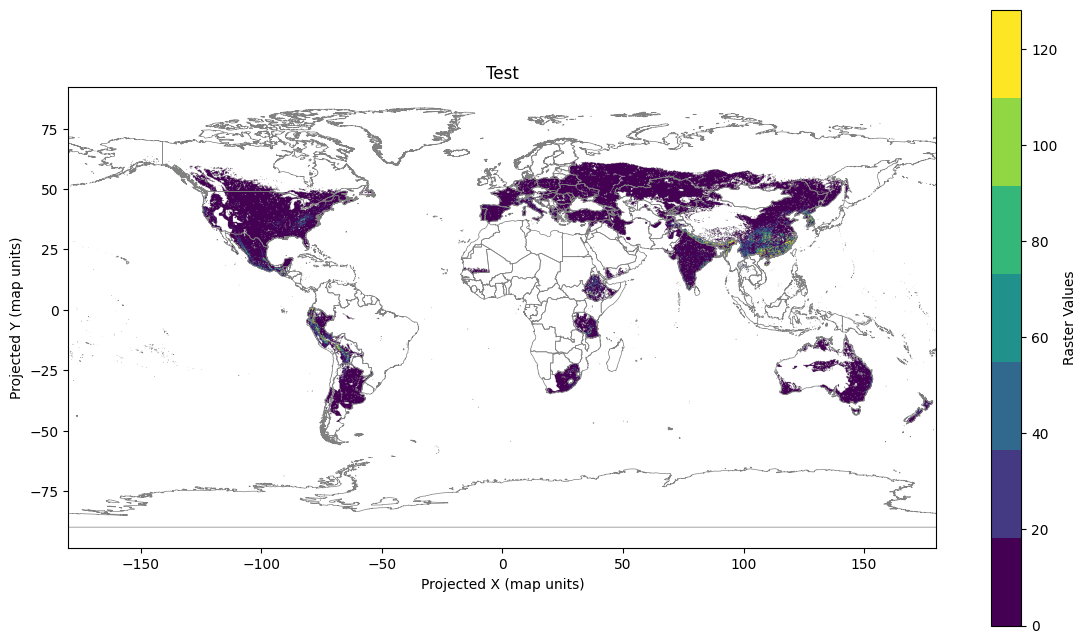

In [51]:
mp.plot_raster_on_world_extremes_cutoff(
    output_test_path,
    title="Test",
    perc_cutoff=0,
    quantiles=7
)

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 102,685 unique values. Min: 0.00. Max: 413.76
Using quantiles
All positives route (quantiles)


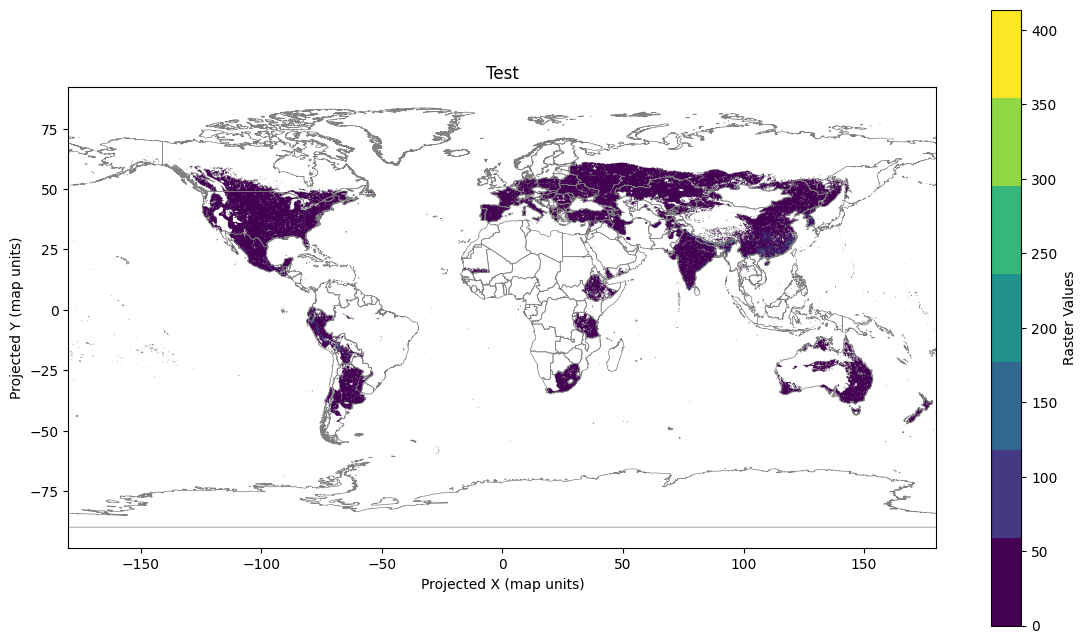

In [52]:
mp.plot_raster_on_world_extremes_cutoff(
    test_fp,
    title="Test",
    perc_cutoff=0,
    quantiles=7
)

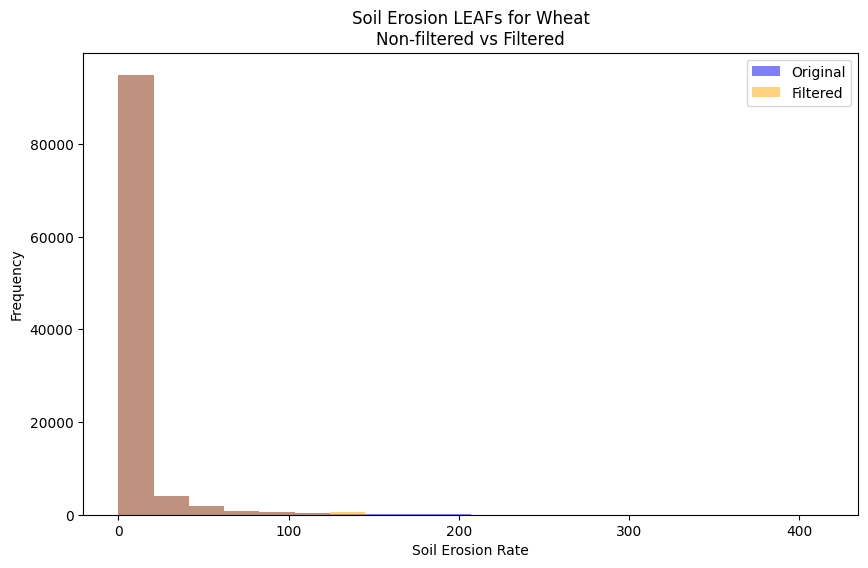

In [60]:
mp.plot_overlapping_histograms(
    raster1_path=test_fp,
    raster2_path=output_test_path,
    title="Soil Erosion LEAFs for Wheat\nNon-filtered vs Filtered",
    x_label="Soil Erosion Rate",
    label1="Original",
    label2="Filtered",
    bins = 20,
    filter_quantiles=0
)

Looks ok, it has filtered the outliers values at 99.5% 

Running the filtering for all

In [63]:
input_folder = "../LEAFs/soil_erosion/raster/"
output_folder = "../LEAFs/soil_erosion/rasters_clipped/"

for file in os.listdir(input_folder):
    # file names
    file_name = os.path.basename(file)
    new_file_name = file_name.replace("se_rate_25km_", "se_rate_25km_clipped_")
    input_path = input_folder + file_name
    output_path = output_folder + new_file_name
    
    # Operation
    filter_raster_outliers(
        input_path=input_path,
        output_path= output_path,
        log_winsor_bounds=log_winsor_bounds,
        apply_local_zscore=True,
        local_window=3,
        local_k=2.5,
        local_min_neighbors=20,
        global_percentile_cap=99.5
    )
    
    print(f"Soil erosion rates clipped for {file_name}. Saved into {output_path}")

C:\Users\loyola\AppData\Local\Temp\ipykernel_24856\1083949865.py:149: RuntimeWarning: overflow encountered in cast
  data = src.read().astype("float32")
C:\Users\loyola\AppData\Local\Temp\ipykernel_24856\1083949865.py:155: RuntimeWarning: overflow encountered in cast
  data[data == nodata] = np.nan


Soil erosion rates clipped for se_rate_25km_Barley_irr_roff_rt.tif. Saved into ../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Barley_irr_roff_rt.tif
Soil erosion rates clipped for se_rate_25km_Barley_irr_ron_rt.tif. Saved into ../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Barley_irr_ron_rt.tif
Soil erosion rates clipped for se_rate_25km_Barley_rf_roff_rt.tif. Saved into ../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Barley_rf_roff_rt.tif
Soil erosion rates clipped for se_rate_25km_Barley_rf_ron_rt.tif. Saved into ../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Barley_rf_ron_rt.tif
Soil erosion rates clipped for se_rate_25km_Broadleaf_Deciduous_Boreal_dry.tif. Saved into ../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_dry.tif
Soil erosion rates clipped for se_rate_25km_Broadleaf_Deciduous_Boreal_moist.tif. Saved into ../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_

C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:218: RuntimeWarning: overflow encountered in cast
  data = src.read(raster_band).astype("float32", copy=False)
C:\Users\loyola\OneDrive - World Wildlife Fund, Inc\Documents\203. Python projects\SBTN_Test\src\sbtn_leaf\map_plotting.py:90: RuntimeWarning: overflow encountered in cast
  out[out == nodata_value] = np.nan


Raster has 278,048 unique values. Min: 0.00. Max: 470.30
Using quantiles
All positives route (quantiles)


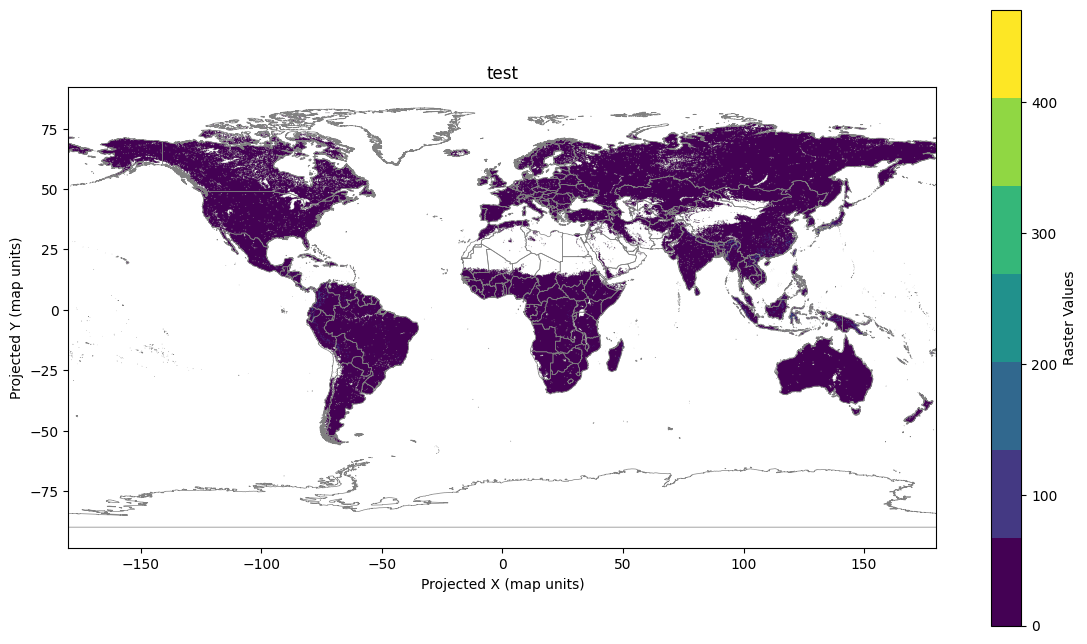

In [66]:
mp.plot_raster_on_world_extremes_cutoff(
   "../LEAFs/soil_erosion/raster/se_rate_25km_Wheat_rf_ron_rt.tif",
   "test",
   perc_cutoff=0,
   quantiles=7
)

Raster has 276,129 unique values. Min: 0.01. Max: 92.12
Using quantiles
All positives route (quantiles)


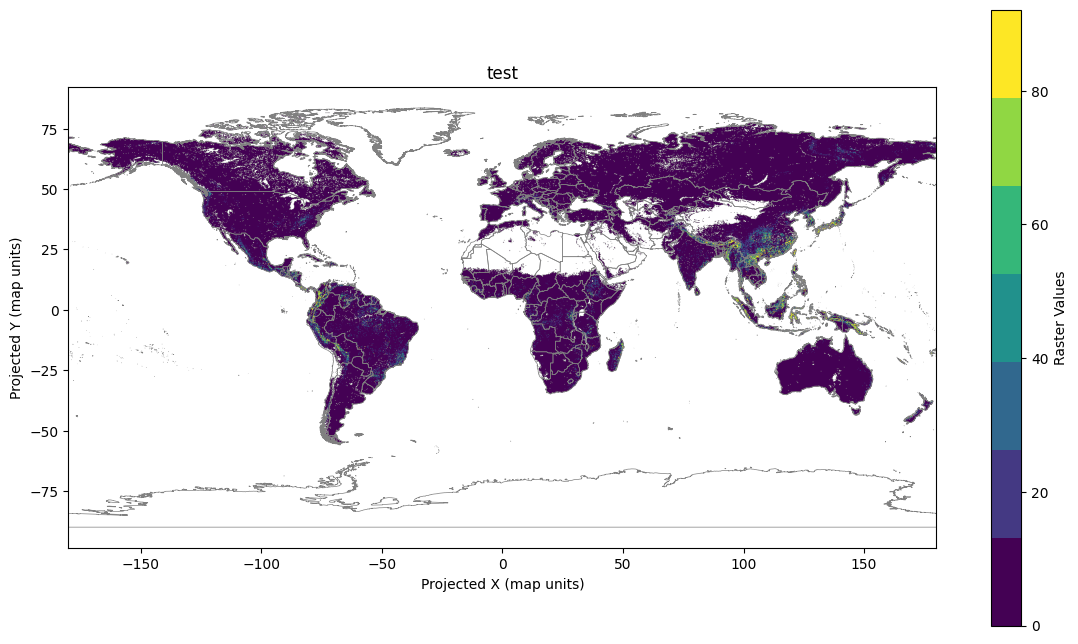

In [65]:
mp.plot_raster_on_world_extremes_cutoff(
   "../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Wheat_rf_ron_rt.tif",
   "test",
   perc_cutoff=0,
   quantiles=7
)

## Step 4 - Country, Sub-country, and Ecoregion averages
After calculating a LEAF soil erosion raster for each land use, it's time to calculate averages per country, sub-country, and ecoregions. These are calculated as area-weighted ones. 

### Step 4.1 - Outliers filtering
Before proceeding to calculate averages per polygon, calculated erosion rates should be analyzed to defined the best way to deal with potential outliers.

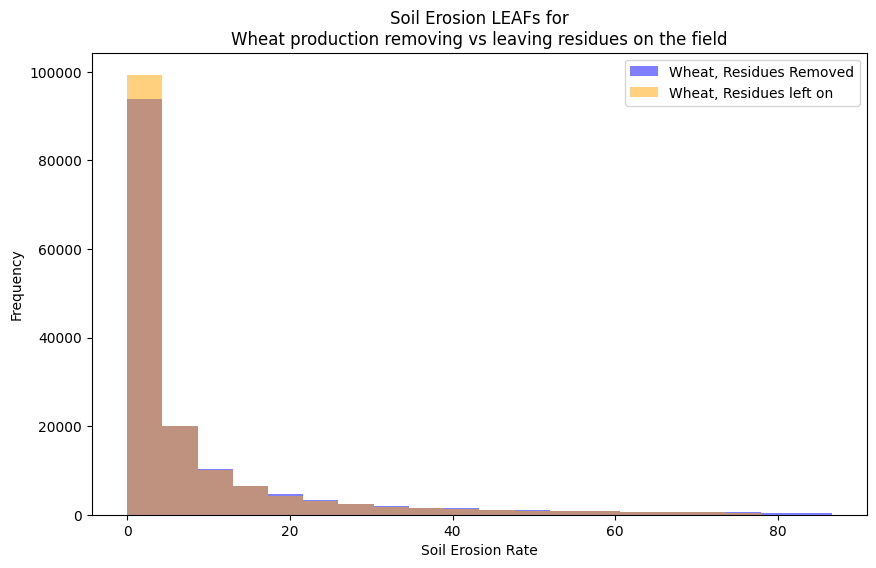

In [33]:
mp.plot_overlapping_histograms(
    raster1_path=wheat_roff_se_leaf_fp,
    raster2_path=wheat_ron_se_leaf_fp,
    title="Soil Erosion LEAFs for\nWheat production removing vs leaving residues on the field",
    x_label="Soil Erosion Rate",
    label1="Wheat, Residues Removed",
    label2="Wheat, Residues left on",
    bins = 20,
    quantiles_tails='right',
    filter_quantiles=0.05
)

In [34]:
with rasterio.open(wheat_roff_se_leaf_fp) as src:
    data = src.read(1, masked=True)

data_flat = data.compressed()

Now transforming with $data_t = \log(1+data)$. As this preserves 0 values (log(1) = 0)

In [35]:
data_t = np.log1p(data_flat)

This looks better distributed

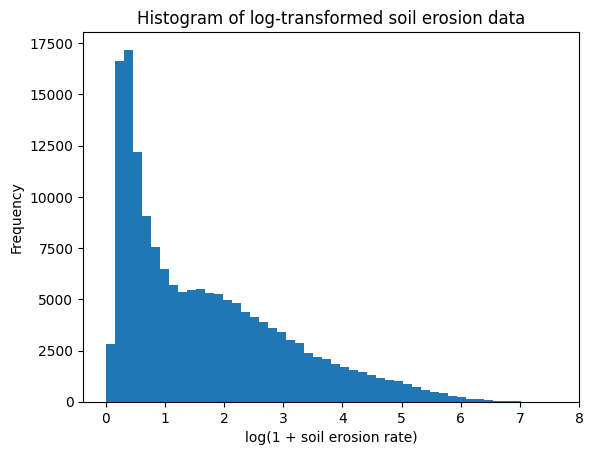

In [36]:
plt.hist(data_t[~np.isnan(data_t)], bins=50)
plt.title("Histogram of log-transformed soil erosion data")
plt.xlabel("log(1 + soil erosion rate)")
plt.ylabel("Frequency")
plt.show()

Now calculating mean and dev of the logtransformed data

In [37]:
mean_dt = np.nanmean(data_t)
std_dt = np.nanstd(data_t)

print(f'Log transformed stats: mean: {mean_dt}, std: {std_dt}')

Log transformed stats: mean: 1.678990030025431, std: 1.3798155592670553


Now filtering the data on mean + 3*std

In [38]:
data_t_f = data_t[data_t <= (mean_dt+3*std_dt)]

Checking how it looks...

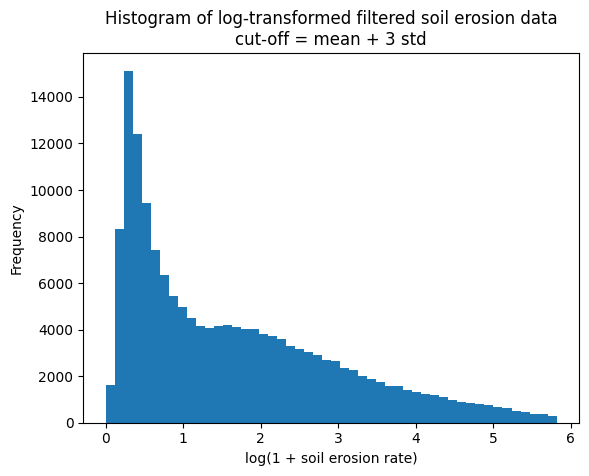

In [39]:
plt.hist(data_t_f[~np.isnan(data_t_f)], bins=50)
plt.title("Histogram of log-transformed filtered soil erosion data\ncut-off = mean + 3 std")
plt.xlabel("log(1 + soil erosion rate)")
plt.ylabel("Frequency")
plt.show()

Which basically cuts the tail close to 6 and over

Un-transforming the data

In [40]:
data_f = np.exp(data_t_f) - 1

Finally comparing mean and std of both:

In [45]:
# Original data
mean_d = np.nanmean(data_flat)
std_d = np.nanstd(data_flat)

# Filtered data
mean_d_f = np.nanmean(data_f)
std_d_f = np.nanstd(data_f)

# Printing
print(f'Unfiltered values - Mean {mean_d} | Std {std_d}')
print(f'Filtered values - Mean {mean_d_f} | Std {std_d_f}')

Unfiltered values - Mean 18.016991082418958 | Std 53.33236638705852
Filtered values - Mean 15.269619829926823 | Std 36.64694849008393


Now comparing how both distribution look.

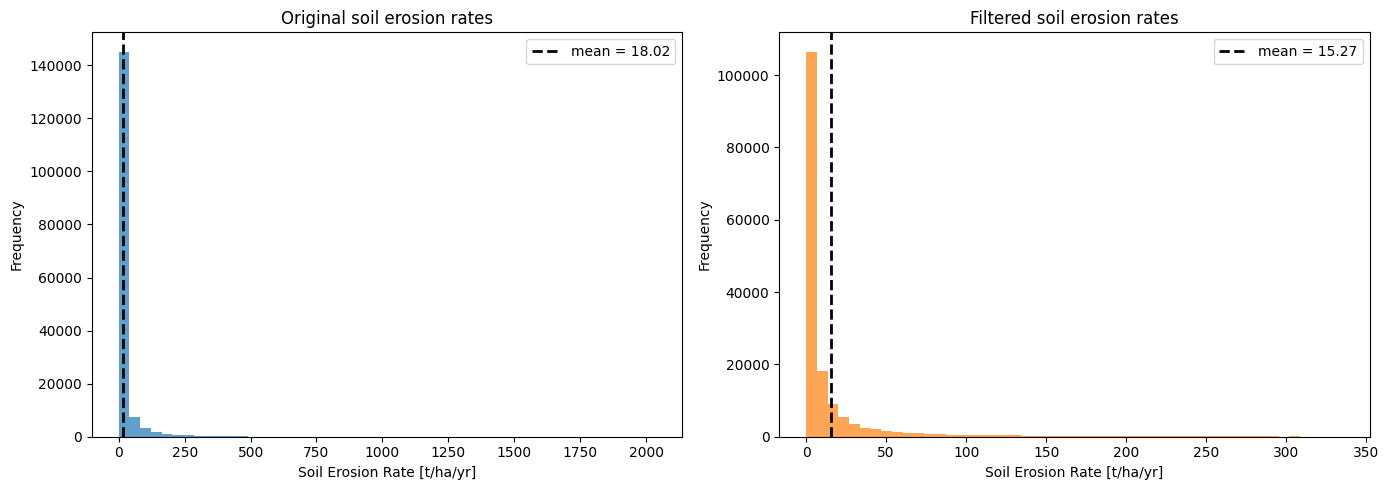

In [46]:
# Plot side-by-side histograms of original and filtered data with vertical mean lines

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original (data_flat)
orig = data_flat[~np.isnan(data_flat)]
axes[0].hist(orig, bins=50, color='C0', alpha=0.7)
axes[0].axvline(mean_d, color='k', linestyle='--', linewidth=2, label=f"mean = {mean_d:.2f}")
axes[0].set_title("Original soil erosion rates")
axes[0].set_xlabel("Soil Erosion Rate [t/ha/yr]")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Right: filtered (data_f)
filt = data_f[~np.isnan(data_f)]
axes[1].hist(filt, bins=50, color='C1', alpha=0.7)
axes[1].axvline(mean_d_f, color='k', linestyle='--', linewidth=2, label=f"mean = {mean_d_f:.2f}")
axes[1].set_title("Filtered soil erosion rates")
axes[1].set_xlabel("Soil Erosion Rate [t/ha/yr]")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()

Which still shows a heavily skewed disitribution, but eliminating the extremely high values over 350 ton soil/ha/year

### Step 4.2 - LEAFs averages

Now that this has been identified, average per geometry are calculated eliminating this outliers

In [152]:
# Defining needed inputs
country_shp = gpd.read_file("../data/CountryLayers/Country_Level0/g2015_2014_0.shp")

In [ ]:
master_key = "ADM0_NAME"

Checking to see if there are duplicated rows...

In [9]:
# Prepare master_gdf if it has several repeated rows
repated_master_key_rows = country_shp[master_key][country_shp[master_key].duplicated()].unique()
repated_master_key_amount = repated_master_key_rows.shape[0]
print(f"There are {repated_master_key_amount} repeated rows, which are:\n {repated_master_key_rows}")

if repated_master_key_amount > 0:
    print('Eliminating duplicat rows')
    corrected_shp = mc.prep_master_unique(country_shp, "ADM0_NAME", strategy="dissolve")

There are 1 repeated rows, which are:
 ['West Bank']
Eliminating duplicat rows


Saving it as it takes a long time...

In [68]:
# corrected_shp.to_file('../data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp')
corrected_shp = gpd.read_file('../data/CountryLayers/Country_Level0/g2015_2014_0_dissolved.shp')

Now running the function. Considering soil erosion rates distribution, we'll use the same outliers filtering method as previously shown.

In [69]:
# Inputs that stay the same
input_folder = "../LEAFs/soil_erosion/rasters_clipped/"
output_folder = "../LEAFs/soil_erosion/"
cf_name = "soil_erosion"
cf_unit = "t soil/ha/yr"
reset_gpck = True

In [70]:
# Inputs that change by area type
area_type = "country"
layer_name = "se_leaf_country"
region_shp = corrected_shp
master_key = "ADM0_NAME"
result_key = "country"

In [78]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    gpckg_name="se_country_clipped",
    input_folder = str(input_folder),
    output_folder = str(output_folder),
    layer_name=layer_name,
    master_gdf=corrected_shp,           # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # or 'ISO_A3', 'ADM1_NAME', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=dict(raster_band = 1, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99),     
    reset_gpkg=reset_gpck,
    run_test=False,                             # Use run test to run the first 3 files
    max_workers=3
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-05-12 15:06:05,658 - INFO - Building 'se_leaf_country' from rasters in ../LEAFs/soil_erosion/rasters_clipped/ into ../LEAFs/soil_erosion/ (../LEAFs/soil_erosion/se_country_clipped.gpkg)



Processing rasters (se_leaf_country):   0%|          | 0/106 [00:00<?, ?raster/s]

2026-05-12 15:06:14,129 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_roff_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_roff_rt...2026-05-12 15:06:14,133 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_ron_rt...

2026-05-12 15:06:14,135 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_roff_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_ron_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_roff_rt...


Processing rasters (se_leaf_country):   0%|          | 0/106 [00:00<?, ?raster/s]

2026-05-12 15:08:34,897 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_ron_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_ron_rt...
2026-05-12 15:08:41,619 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_dry...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_dry...
2026-05-12 15:08:45,937 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_moist...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_moist...
2026-05-12 15:10:12,258 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_dry...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_dry...
2026-05-12 15:10:22,524 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_moist...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_te

Wrote 87768 rows into ../LEAFs/soil_erosion/se_country_clipped.gpkg


Checking outputs

In [81]:
gdf_test_values = gpd.read_file(gpkg_path, layer="se_leaf_country")
gdf_test_values.sort_values(by=["cf"], ascending=False).head()

,ADM0_NAME,flow_name,cf,cf_median,cf_std,_source_file
27988,Hong Kong,se_rate_25km_clipped_Urban,2012.055176,2092.303955,138.994965,se_rate_25km_clipped_Urban.tif
27934,Comoros,se_rate_25km_clipped_Urban,1881.906982,1881.906982,0.000000,se_rate_25km_clipped_Urban.tif
28118,Taiwan,se_rate_25km_clipped_Urban,1123.226685,1121.085571,696.812622,se_rate_25km_clipped_Urban.tif
27959,Fiji,se_rate_25km_clipped_Urban,1082.634399,1044.345093,512.265503,se_rate_25km_clipped_Urban.tif
10864,Guadeloupe,se_rate_25km_clipped_Irrigated_Sugarbeet,996.930664,996.930664,0.000000,se_rate_25km_clipped_Irrigated_Sugarbeet.tif


And it can be seen that the output has all values. Opening the dataset it can be seen it include NaNs.

To plot it, the geoemtries layer need to be imported as:

In [82]:
gdf_test_geometries = gpd.read_file(gpkg_path, layer="geometry_layer")

And then merged.

In [83]:
gdf_test = gdf_test_geometries.merge(gdf_test_values.drop(columns="_source_file"), how="left", on="ADM0_NAME")

Plotting, using Broadleaf_Deciduous_Cold_temperate_dry as example

In [123]:
test_flow = "se_rate_25km_clipped_Wheat_irr_ron_rt"

In [ ]:
wheat_rainfed_roff = gdf_test[gdf_test["flow_name"]==test_flow]

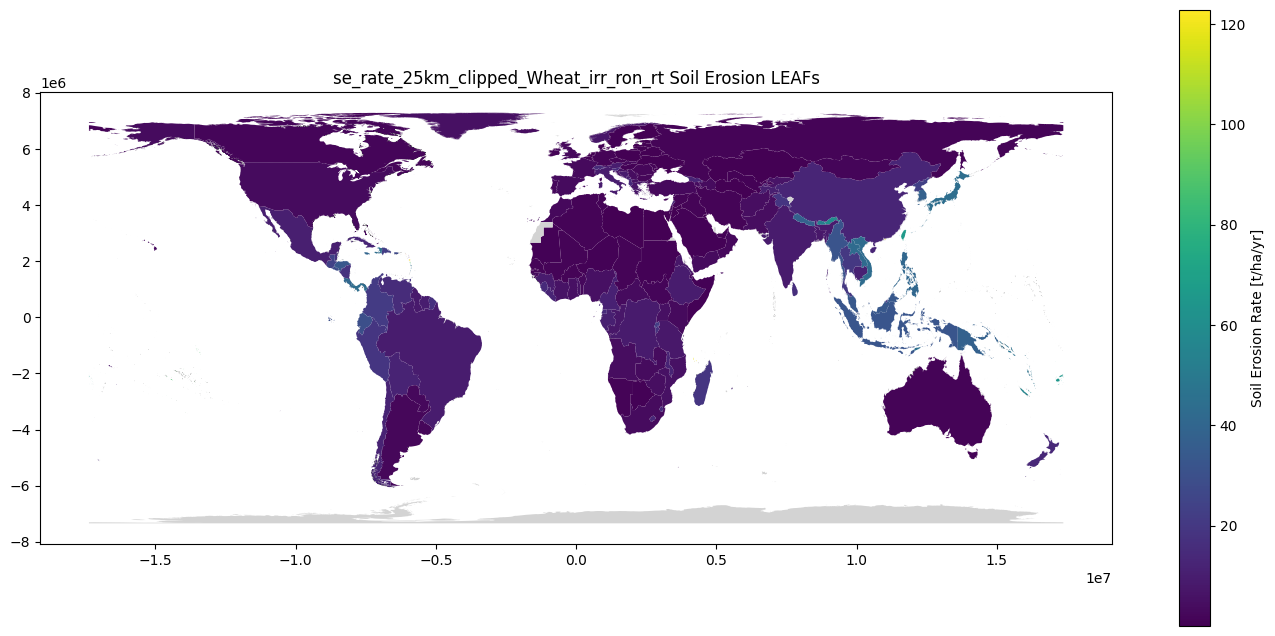

In [125]:
fig, ax = plt.subplots(figsize=(14, 8)) 
wheat_rainfed_roff.plot(column="cf", ax=ax, cmap="viridis", 
           legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}) 

ax.set_title(f"{test_flow} Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

Checking df

In [86]:
df_results.sort_values(by="value", ascending=False).head()

,ADM0_NAME,flow_name,metric,value
84016,Hong Kong,se_rate_25km_clipped_Urban,cf_median,2092.3040
83740,Hong Kong,se_rate_25km_clipped_Urban,cf_mean,2012.0552
83686,Comoros,se_rate_25km_clipped_Urban,cf_mean,1881.9070
83962,Comoros,se_rate_25km_clipped_Urban,cf_median,1881.9070
83870,Taiwan,se_rate_25km_clipped_Urban,cf_mean,1123.2267


It can be seen that holds the same information

##### Sub-Country
Repeating the process with subcountries

First, correcting the shapefile to eliminate duplicated names, if any

In [95]:
# Inputs that change by area type
area_type = "subcountry"
layer_name = "se_leaf_subcountry"
corrected_shp = gpd.read_file('../data/CountryLayers/SubCountry_Level1/g2015_2014_1.shp')
master_key = "ADM1_CODE"
result_key = "ADM1_CODE"

So there are now repeated sub-country geom IDs, so we'll go ahead and do the calculations based on that

Running the code

In [89]:
gpkg_path_sc, df_results_sc = mc.build_cfs_gpkg_from_rasters(
    gpckg_name="se_subcountry_clipped",
    input_folder = str(input_folder),
    output_folder = str(output_folder),
    layer_name=layer_name,
    master_gdf=corrected_shp,           # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # or 'ISO_A3', 'ADM1_CODE', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    input_raster_key_startswith=None,
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=dict(raster_band = 1, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99),     # Chooses the raster band. Due to outliers in crops, setting it to windsorize, replacing all values outside 1, 99 percentiles with those values.
    reset_gpkg=True,
    run_test=False,
    max_workers=4
)

print(f"Wrote {df_results_sc.shape[0]} rows into {gpkg_path_sc}")

2026-05-12 21:45:16,337 - INFO - Building 'soc_leaf_subcountry' from rasters in ../LEAFs/soil_erosion/rasters_clipped/ into ../LEAFs/soil_erosion/ (../LEAFs/soil_erosion/se_subcountry_clipped.gpkg)



Processing rasters (soc_leaf_subcountry):   0%|          | 0/106 [00:00<?, ?raster/s]

2026-05-12 21:45:28,265 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_roff_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_roff_rt...2026-05-12 21:45:28,283 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_ron_rt...

2026-05-12 21:45:28,285 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_roff_rt...
2026-05-12 21:45:28,300 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_ron_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_ron_rt...


Processing rasters (soc_leaf_subcountry):   0%|          | 0/106 [00:00<?, ?raster/s]

Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_roff_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_ron_rt...
2026-05-12 21:48:15,418 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_dry...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_dry...
2026-05-12 21:48:20,643 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_moist...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_moist...
2026-05-12 21:48:27,939 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_dry...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_dry...
2026-05-12 21:48:31,321 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_moist...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_moist...
2026-05-12 21:4

Wrote 1088196 rows into ../LEAFs/soil_erosion/se_subcountry_clipped.gpkg


Checking datasets were generated ok

In [90]:
gdf_sc_geometries = gpd.read_file(gpkg_path_sc, layer="geometry_layer")

In [94]:
gdf_sc_values = gpd.read_file(gpkg_path_sc, layer="se_leaf_subcountry")
gdf_sc_values.sort_values(by=["cf"], ascending=False).head(10)

,ADM1_CODE,flow_name,cf,cf_median,cf_std,_source_file
349023,40188,se_rate_25km_clipped_Urban,2092.303955,2092.303955,0.000000,se_rate_25km_clipped_Urban.tif
347304,910,se_rate_25km_clipped_Urban,2012.055176,2092.303955,138.994965,se_rate_25km_clipped_Urban.tif
345641,967,se_rate_25km_clipped_Urban,1881.906982,1881.906982,0.000000,se_rate_25km_clipped_Urban.tif
347618,2962,se_rate_25km_clipped_Urban,1786.075073,1919.620239,138.947739,se_rate_25km_clipped_Urban.tif
347275,1669,se_rate_25km_clipped_Urban,1758.596680,1918.085815,415.224762,se_rate_25km_clipped_Urban.tif
347753,41310,se_rate_25km_clipped_Urban,1620.984009,1933.990234,530.749451,se_rate_25km_clipped_Urban.tif
347613,2957,se_rate_25km_clipped_Urban,1611.151855,1730.007324,349.256287,se_rate_25km_clipped_Urban.tif
347762,639,se_rate_25km_clipped_Urban,1592.933838,1756.112793,437.509491,se_rate_25km_clipped_Urban.tif
347751,628,se_rate_25km_clipped_Urban,1573.013306,2021.300171,637.792053,se_rate_25km_clipped_Urban.tif
347422,3328,se_rate_25km_clipped_Urban,1571.127686,1811.004883,494.271606,se_rate_25km_clipped_Urban.tif


In [96]:
df_results_sc.head()

,ADM0_NAME,ADM1_NAME,ADM1_CODE,flow_name,metric,value
0,Burundi,Bubanza,40542,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,26.452946
1,Burundi,Bujumbura Mairie,40543,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,37.379555
2,Burundi,Bujumbura Rural,40544,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,29.491830
3,Burundi,Bururi,40545,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,18.305384
4,Burundi,Cankuzo,40546,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,6.271389


Now checking some of the results for Broadleaf_Deciduous_Cold_temperate_dry.

In [97]:
gdf_sc = gdf_sc_geometries.merge(gdf_sc_values, how="left", on="ADM1_CODE").drop(columns="_source_file")

In [126]:
gdf_sc_testflow = gdf_sc[gdf_sc["flow_name"] == test_flow]

Now plotting

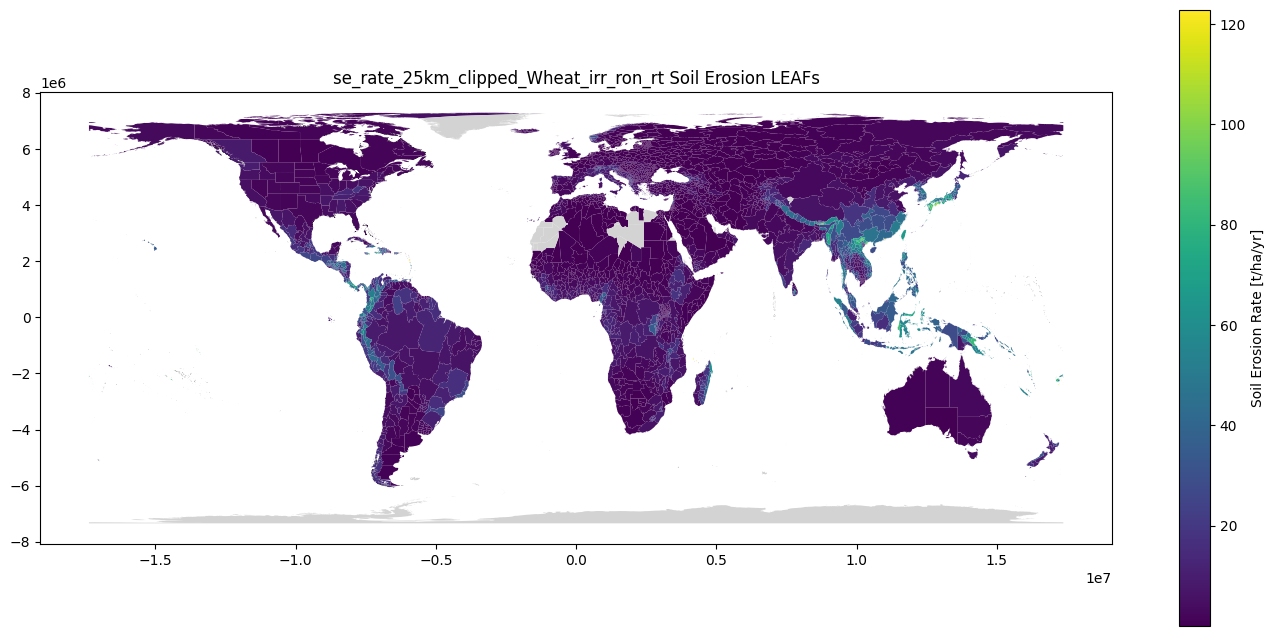

In [127]:
fig, ax = plt.subplots(figsize=(14, 8))
gdf_sc_testflow.plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title(f"{test_flow} Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

Just Colombia, as it has high values compared to the rest

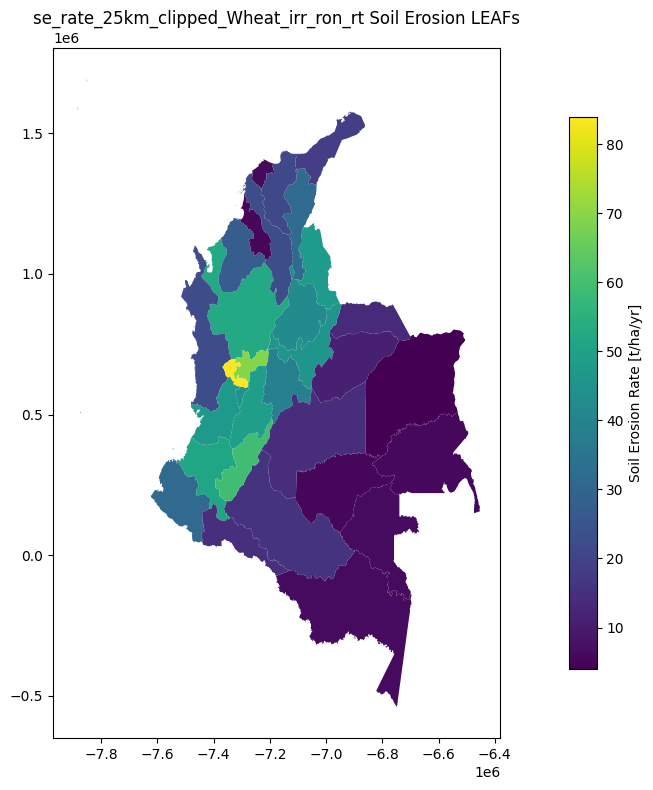

In [129]:
fig, ax = plt.subplots(figsize=(14, 8))
gdf_sc_testflow[gdf_sc_testflow["ADM0_NAME"] == "Colombia"].plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title(f"{test_flow} Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

In [105]:
test_raster = "../LEAFs/soil_erosion/rasters_clipped/se_rate_25km_clipped_Wheat_irr_ron_rt.tif"

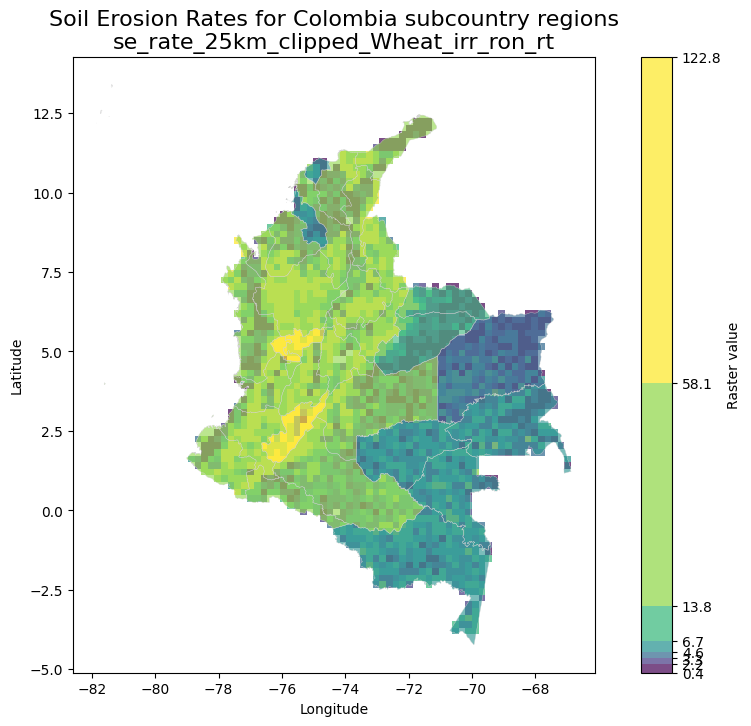

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Soil Erosion Rates for Colombia subcountry regions\nse_rate_25km_clipped_Wheat_irr_ron_rt'}, xlabel='Longitude', ylabel='Latitude'>)

In [130]:
mp.plot_raster_over_gdf_showpolygonvalues(
    gdf_sc_testflow[gdf_sc_testflow["ADM0_NAME"] == "Colombia"],
    raster_path=test_raster,
    title=f"Soil Erosion Rates for Colombia subcountry regions\n{test_flow}",
    polygon_linewidth=0.25,
    polygon_value_col="cf",
    match_color_scale=True,
    n_quantiles=7
)

So it can be seen than the average worked fine. It can also be seen that the overlap in some regions is not large, and wheat production is concentrated in just a couple of strips, with averages going between 12 to 500 ton soil/ha/yr, comparing it witht he average of 252 that the country gives.

It can also be seen that very high-values in some regions are overlapped minimally, which highlight the need to favour LEAFs defined at a finer resolution than sub-countries for companies.

### 4.3 - Ecoregions

Finally, ecoregion averages are calculated.

##### Checking shapefile

Ecoregions are also processed by ecoregion ID instead of name, so checking if there're ducplicated of those

In [113]:
# Inputs that change by area type
area_type = "ecoregion"
layer_name = "se_leaf_ecoregions"
master_key = "ECO_ID"
result_key = "er_id"
er_gdf = gpd.read_file("../data/Ecoregions2017/Ecoregions2017.shp")

##### Calculating averages

In [115]:
gpkg_path, df_results = mc.build_cfs_gpkg_from_rasters(
    gpckg_name="se_ecoregions_clipped",
    input_folder = str(input_folder),
    output_folder = str(output_folder),
    layer_name=layer_name,
    master_gdf=er_gdf,                  # e.g., countries, subcountries, or ecoregions
    master_key=master_key,              # or 'ISO_A3', 'ADM1_CODE', 'ECO_NAME'
    result_key=result_key,              # must match the column emitted by your calc gdf
    cf_name=cf_name,
    cf_unit=cf_unit,
    area_type=area_type,
    calc_kwargs=dict(raster_band = 1, outlier_method="log1p_win", q_low = 0.01, q_high = 0.99),
    reset_gpkg=True,
    run_test=False, 
    max_workers=4     
)

print(f"Wrote {df_results.shape[0]} rows into {gpkg_path}")

2026-05-13 10:20:59,104 - INFO - Building 'se_leaf_ecoregions' from rasters in ../LEAFs/soil_erosion/rasters_clipped/ into ../LEAFs/soil_erosion/ (../LEAFs/soil_erosion/se_ecoregions_clipped.gpkg)



Processing rasters (se_leaf_ecoregions):   0%|          | 0/106 [00:00<?, ?raster/s]

2026-05-13 10:21:08,892 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_roff_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_roff_rt...2026-05-13 10:21:08,909 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_ron_rt...

2026-05-13 10:21:08,910 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_roff_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_irr_ron_rt...
2026-05-13 10:21:08,924 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_ron_rt...


Processing rasters (se_leaf_ecoregions):   0%|          | 0/106 [00:00<?, ?raster/s]

Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_roff_rt...
Calculating soil_erosion for se_rate_25km_clipped_Barley_rf_ron_rt...
2026-05-13 10:25:31,110 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_dry...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_dry...
2026-05-13 10:25:34,339 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_moist...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Boreal_moist...
2026-05-13 10:25:34,588 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_dry...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_dry...
2026-05-13 10:25:34,742 - INFO - Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_moist...
Calculating soil_erosion for se_rate_25km_clipped_Broadleaf_Deciduous_Cold_temperate_moist...
2026-05-13 10:2

Wrote 269346 rows into ../LEAFs/soil_erosion/se_ecoregions_clipped.gpkg


Checking datasets were generated ok

In [140]:
gpkg_path_er = gpkg_path

In [141]:
gdf_er_geometries = gpd.read_file(gpkg_path_er, layer="geometry_layer")

In [142]:
gdf_er_values = gpd.read_file(gpkg_path_er, layer="se_leaf_ecoregions")
gdf_er_values.sort_values(by=["cf"], ascending=False).head(10)

,ECO_ID,flow_name,cf,cf_median,cf_std,_source_file
85721,4,se_rate_25km_clipped_Urban,1881.906982,1881.906982,0.000000,se_rate_25km_clipped_Urban.tif
86347,162,se_rate_25km_clipped_Urban,1595.456787,1583.468872,399.275055,se_rate_25km_clipped_Urban.tif
85871,141,se_rate_25km_clipped_Urban,1487.540405,1554.357056,472.720642,se_rate_25km_clipped_Urban.tif
86065,307,se_rate_25km_clipped_Urban,1436.786743,1588.117920,478.657043,se_rate_25km_clipped_Urban.tif
85940,303,se_rate_25km_clipped_Urban,1397.949097,1552.586670,418.148438,se_rate_25km_clipped_Urban.tif
85787,461,se_rate_25km_clipped_Urban,1293.340088,1265.489624,503.244659,se_rate_25km_clipped_Urban.tif
86247,157,se_rate_25km_clipped_Urban,1246.843262,1289.812744,547.676392,se_rate_25km_clipped_Urban.tif
86265,506,se_rate_25km_clipped_Urban,1244.247314,1238.070679,515.044189,se_rate_25km_clipped_Urban.tif
86253,305,se_rate_25km_clipped_Urban,1242.424561,1499.169678,544.454590,se_rate_25km_clipped_Urban.tif
85712,226,se_rate_25km_clipped_Urban,1229.663696,1276.287476,440.976318,se_rate_25km_clipped_Urban.tif


In [145]:
df_results_er =df_results
df_results_er.head()

,ECO_ID,flow_name,metric,value,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM
0,117,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,NaN,Adelie Land tundra,11.0,Tundra,Antarctica
1,135,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,21.762240,Admiralty Islands lowland rain forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Australasia
2,785,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,5.545331,Aegean and Western Turkey sclerophyllous and m...,12.0,"Mediterranean Forests, Woodlands & Scrub",Palearctic
3,807,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,7.512600,Afghan Mountains semi-desert,13.0,Deserts & Xeric Shrublands,Palearctic
4,404,se_rate_25km_clipped_Barley_irr_ron_rt,cf_mean,1.293749,Ahklun and Kilbuck Upland Tundra,11.0,Tundra,Nearctic


Results look ok. Merging the geometries and plotting

In [147]:
gdf_er = gdf_er_geometries.merge(gdf_er_values, how="left", on="ECO_ID").drop(columns="_source_file")

Filtering for a flow...

In [148]:
gdf_er_testflow = gdf_er[gdf_er["flow_name"] == test_flow]

Now plotting

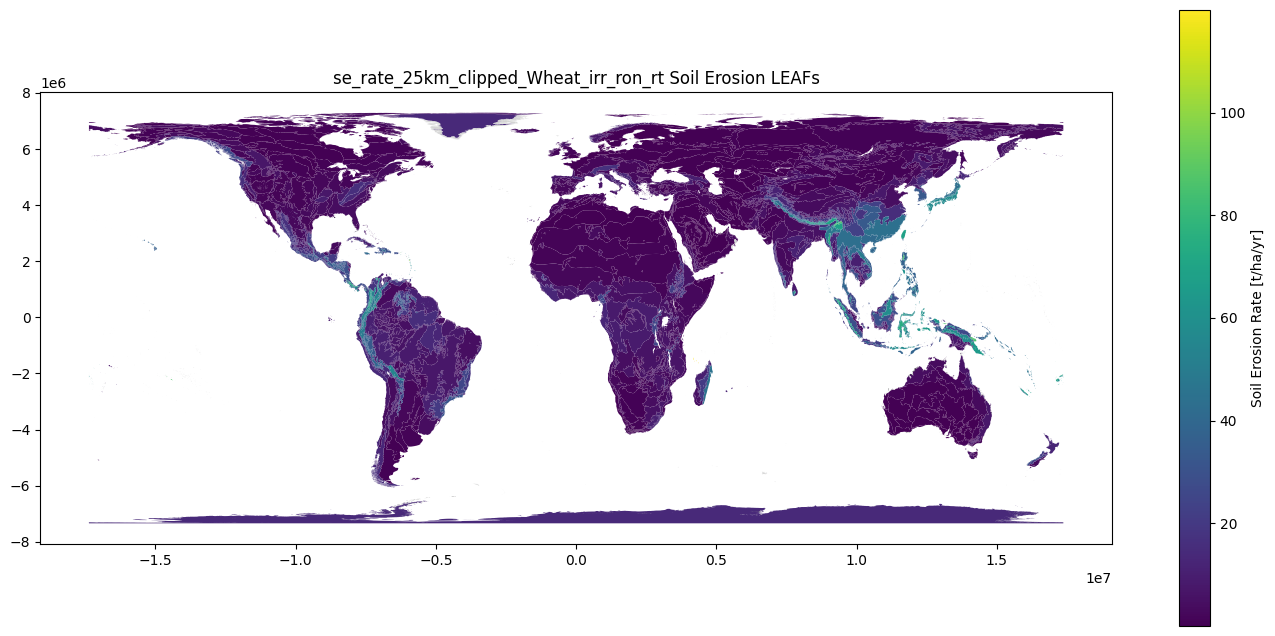

In [150]:
fig, ax = plt.subplots(figsize=(14, 8))
gdf_er_testflow.plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title(f"{test_flow} Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

Now zooming into the ecoregions around Colombia for a better comparison. These are:

In [ ]:
country_shp_reproj = country_shp.to_crs(er_gdf.crs)

In [166]:
co_ers = er_gdf.overlay(country_shp_reproj[country_shp_reproj["ADM0_NAME"]=="Colombia"])

In [168]:
co_ers = co_ers.merge(gdf_er_testflow[["ECO_ID", "cf", "cf_median", "cf_std"]], how="left", on= "ECO_ID")
co_ers.head()

,OBJECTID,ECO_NAME,BIOME_NUM,BIOME_NAME,REALM,ECO_BIOME_,NNH,ECO_ID,SHAPE_LENG_1,SHAPE_AREA_1,...,ADM0_CODE,ADM0_NAME,STR0_YEAR,EXP0_YEAR,SHAPE_LENG_2,SHAPE_AREA_2,geometry,cf,cf_median,cf_std
0,23.0,Amazon-Orinoco-Southern Caribbean mangroves,14.0,Mangroves,Neotropic,NO14,1,611,139.824908,3.346216,...,57,Colombia,1000,3000,96.745853,92.806433,"MULTIPOLYGON (((-77.27059 8.51664, -77.2708 8....",5.511732,2.486904,9.514460
1,37.0,Apure-Villavicencio dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,3,520,44.540782,5.587565,...,57,Colombia,1000,3000,96.745853,92.806433,"MULTIPOLYGON (((-74.25538 2.89972, -74.24964 2...",10.667504,3.326208,18.453766
2,102.0,Caqueta moist forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Neotropic,NO01,2,446,104.726611,14.899936,...,57,Colombia,1000,3000,96.745853,92.806433,"MULTIPOLYGON (((-75.07819 1.93542, -75.10146 1...",6.750697,5.442109,4.619380
3,111.0,Catatumbo moist forests,1.0,Tropical & Subtropical Moist Broadleaf Forests,Neotropic,NO01,2,447,25.018207,1.871315,...,57,Colombia,1000,3000,96.745853,92.806433,"POLYGON ((-72.379 8.10476, -72.38215 8.09748, ...",22.138922,8.494643,27.235727
4,112.0,Cauca Valley dry forests,2.0,Tropical & Subtropical Dry Broadleaf Forests,Neotropic,NO02,4,526,19.569979,0.596234,...,57,Colombia,1000,3000,96.745853,92.806433,"POLYGON ((-75.48669 7.22852, -75.48794 7.21897...",58.611145,57.484486,37.019379


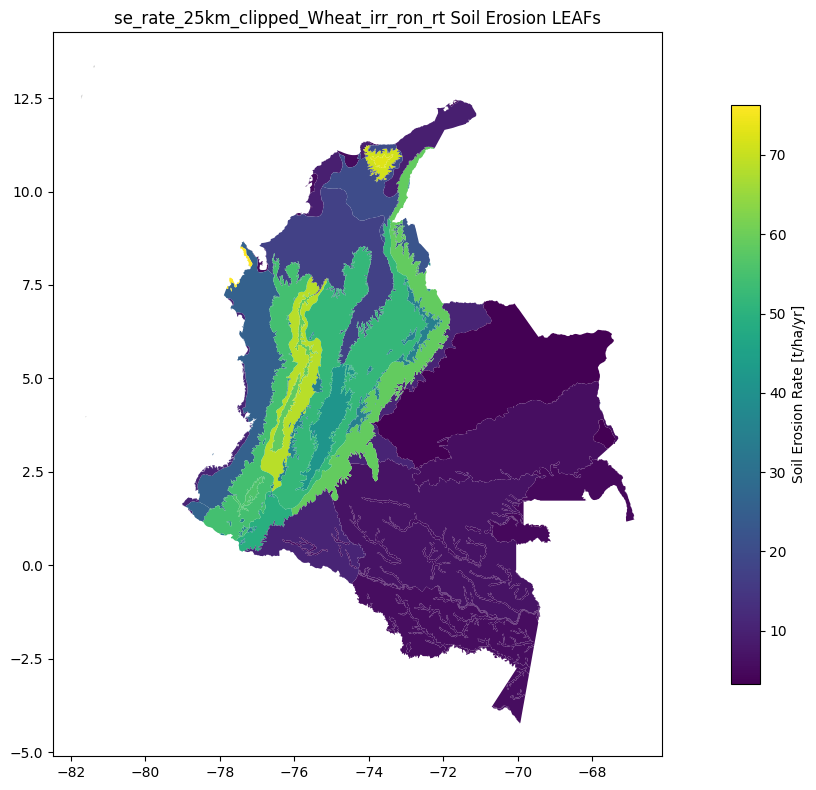

In [169]:
fig, ax = plt.subplots(figsize=(14, 8))
co_ers.plot(column="cf", ax=ax, cmap="viridis", legend=True, 
           legend_kwds={"label": "Soil Erosion Rate [t/ha/yr]", "shrink": 0.8}, 
           missing_kwds={"color": "lightgrey", "label": "No value"}
           ) 

ax.set_title(f"{test_flow} Soil Erosion LEAFs")
plt.tight_layout() 
plt.show()

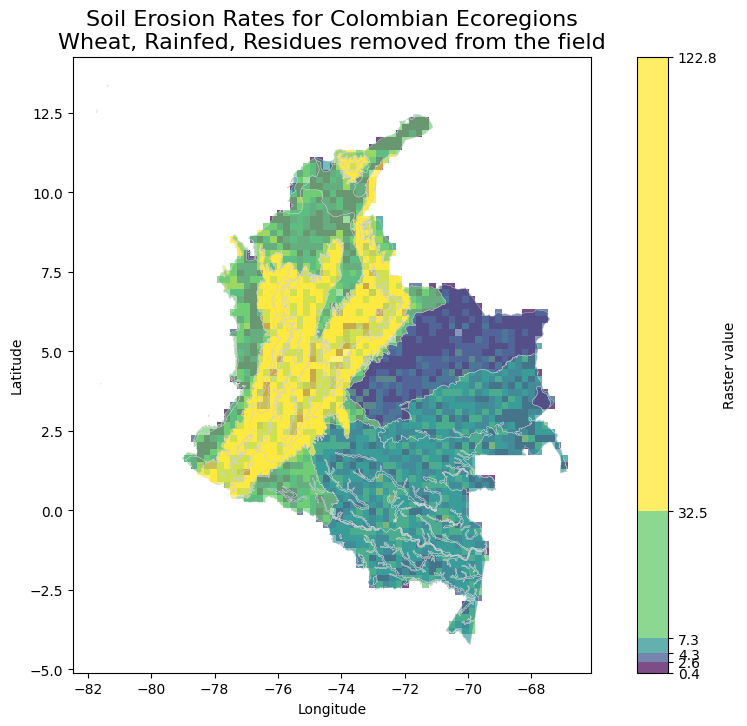

(<Figure size 1200x800 with 2 Axes>,
 <Axes: title={'center': 'Soil Erosion Rates for Colombian Ecoregions\nWheat, Rainfed, Residues removed from the field'}, xlabel='Longitude', ylabel='Latitude'>)

In [171]:
mp.plot_raster_over_gdf_showpolygonvalues(
    co_ers,test_raster,  
    title="Soil Erosion Rates for Colombian Ecoregions\nWheat, Rainfed, Residues removed from the field",
    polygon_linewidth=0.25, polygon_value_col="cf", match_color_scale=True, n_quantiles=5)

It can be seen that there's a better alignment between pixel coverage and some ecoregions, and has a similar range of values than sub-country averages.